
<style>
.nh-main{
    background:linear-gradient(135deg,#111827,#312e81);
    border:2px solid #818cf8;
    border-radius:18px;
    padding:24px 30px;
    margin:12px 0 26px;
    color:#fff;
    box-shadow:0 6px 20px rgba(0,0,0,.25);
}
.nh-main h1{margin:0 0 8px;color:#fff;font-size:30px}
.nh-main p{margin:0;color:#e0e7ff;font-size:16px}

.nh-banner{
    border-radius:16px;
    padding:20px 26px;
    margin:24px 0 18px;
    color:#fff;
    border:2px solid rgba(255,255,255,.45);
    box-shadow:0 6px 18px rgba(0,0,0,.20);
}
.nh-banner h2{margin:0 0 6px;color:#fff;font-size:24px}
.nh-banner p{margin:0;color:#fff;font-size:15px}

.nh-step{
    border-radius:11px;
    padding:10px 16px;
    margin:14px 0 8px;
    border-left:7px solid;
    box-shadow:0 2px 8px rgba(0,0,0,.10);
}
.nh-step h3{margin:0;font-size:18px}

.nh-summary{
    border-radius:15px;
    padding:16px 22px;
    margin:20px 0 26px;
    border:2px solid;
    box-shadow:0 4px 12px rgba(0,0,0,.12);
}
.nh-summary h3{margin:0 0 8px}
.nh-summary ul{margin:6px 0 0 20px}
</style>



<div class="nh-main">
<h1>🏨 NARAHOTEIS | Auditoria e Tratamento dos Dados</h1>
<p>Diagnóstico de qualidade • limpeza • padronização • validação • preparação para análise</p>
</div>

### Objetivo
- Nós realizamos a auditoria e o tratamento das bases do projeto Nara Hotéis.
- Nós identificamos inconsistências, corrigimos os registros indicados e validamos os resultados.
- Nós organizamos as bases para deixá-las prontas para análise.


In [102]:
import pandas as pd
import numpy as np


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Carregamento e consolidação</h3>
</div>

- Nós carregamos os dois lotes da base de clientes.
- Usamos `pd.read_csv()` com separador `;` e decimal `,`.
- Consolidamos os lotes em um único DataFrame com `pd.concat()`.
- A partir daqui, trabalhamos com `df_clientes_final`.

In [103]:
caminho_cliente_lote1 = r"clientes.csv"
caminho_cliente_lote2 = r"clientes_novos.csv"

df_clientes_lote1 = pd.read_csv(caminho_cliente_lote1,sep=";",decimal=",")
df_clientes_lote2 = pd.read_csv(caminho_cliente_lote2,sep=";",decimal=",")

df_clientes_final = pd.concat([df_clientes_lote1, df_clientes_lote2], ignore_index=True)
df_clientes_final

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
0,1,Otavio Reis,São Paulo,SP,18-25,PJ
1,2,Larissa Sousa,Curitiba,SC,18-25,pessoa fisica
2,3,Tatiana Coelho,Rio de Janeiro,CE,65+,Corporativo
3,4,Wilson Duarte,Brasília,AM,26-35,corporativo
4,5,Gabriela Lima,Rio de Janeiro,SP,46-55,Pessoa Física
...,...,...,...,...,...,...
316,316,Priscila Guimarães,Lisboa,EX,NaN,PF
317,317,Rodrigo Vasques,Rio de Janeiro,RJ,36-45,PF
318,318,Sabrina Leitão,Brasília,DF,46-55,PF
319,319,Thiago Bicalho,Belo Horizonte,MG,46-55,Pessoa Jurídica


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Correção de identificador</h3>
</div>

- Nós verificamos o registro do cliente com `id_cliente` 47.
- Identificamos o registro de **Carlos Neto** e corrigimos o identificador para `401`.
- Em seguida, conferimos os registros relacionados aos nomes envolvidos.

In [104]:
df_clientes_final[df_clientes_final['id_cliente'] == 47]
df_clientes_final.loc[(df_clientes_final['id_cliente'] == 47) & (df_clientes_final['nome'] == 'Carlos Neto'),'id_cliente'] = 401

df_clientes_final.loc[df_clientes_final['nome'].isin(['Wesley Araujo', 'Carlos Neto'])]

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
8,9,Wesley Araujo,Belo Horizonte,ES,NaN,Corporativo
46,47,Wesley Araujo,Recife,ES,65+,Pessoa Física
53,54,Wesley Araujo,Curitiba,PE,36-45,Corporativo
66,67,Carlos Neto,Salvador,BA,26-35,Corporativo
67,68,Carlos Neto,São Paulo,SP,65+,Corporativo
76,77,Wesley Araujo,Curitiba,ES,65+,Pessoa Física
85,86,Carlos Neto,Fortaleza,ES,46-55,Corporativo
90,91,Wesley Araujo,Brasília,PE,46-55,corporativo
125,126,Carlos Neto,Salvador,MG,65+,PJ
126,127,Wesley Araujo,Belo Horizonte,PR,46-55,Pessoa Física


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Verificação de duplicidades</h3>
</div>

- Nós verificamos se existem `id_cliente` duplicados.
- Essa etapa permite identificar possíveis conflitos de identificação antes das demais correções.

In [105]:
df_clientes_final['id_cliente'].duplicated().sum()

np.int64(0)

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Dimensão da base</h3>
</div>

- Nós verificamos o número de linhas e colunas da base com `shape`.

In [106]:
df_clientes_final.shape



(321, 6)

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Inspeção dos registros</h3>
</div>

- Nós visualizamos as primeiras linhas para conferir a estrutura e o conteúdo inicial.

In [107]:
df_clientes_final.head(5)


,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
0,1,Otavio Reis,São Paulo,SP,18-25,PJ
1,2,Larissa Sousa,Curitiba,SC,18-25,pessoa fisica
2,3,Tatiana Coelho,Rio de Janeiro,CE,65+,Corporativo
3,4,Wilson Duarte,Brasília,AM,26-35,corporativo
4,5,Gabriela Lima,Rio de Janeiro,SP,46-55,Pessoa Física


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Inspeção dos registros finais</h3>
</div>

- Nós visualizamos as últimas linhas para conferir o conteúdo final da base.

In [108]:
df_clientes_final.tail(3)

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
318,318,Sabrina Leitão,Brasília,DF,46-55,PF
319,319,Thiago Bicalho,Belo Horizonte,MG,46-55,Pessoa Jurídica
320,320,Vivian Lacerda,Buenos Aires,EX,56-65,Pessoa Jurídica


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Tipos e estrutura</h3>
</div>

- Nós verificamos a estrutura da base com `info()`.
- Conferimos tipos de dados e quantidade de valores não nulos.

In [109]:
df_clientes_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   id_cliente     321 non-null    int64
 1   nome           321 non-null    str  
 2   cidade_origem  321 non-null    str  
 3   estado_origem  321 non-null    str  
 4   faixa_etaria   290 non-null    str  
 5   tipo_cliente   321 non-null    str  
dtypes: int64(1), str(5)
memory usage: 15.2 KB


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Valores ausentes</h3>
</div>

- Nós calculamos a quantidade e o percentual de valores ausentes por coluna.
- Identificamos `faixa_etaria` como campo com valores ausentes.
- Preenchemos esses registros com **`Não informado`**.
- Depois, conferimos novamente os valores ausentes.

In [110]:
# Contagem de nulos por coluna

(df_clientes_final.isnull().sum() / len(df_clientes_final) * 100).round(1)

# Tratar os valores ausentes
df_clientes_final['faixa_etaria'] = df_clientes_final['faixa_etaria'].fillna('Não informado')

df_clientes_final.isnull().sum()

id_cliente       0
nome             0
cidade_origem    0
estado_origem    0
faixa_etaria     0
tipo_cliente     0
dtype: int64

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Distribuição da faixa etária</h3>
</div>

- Nós verificamos a frequência de cada categoria de `faixa_etaria` após o tratamento.

In [111]:
df_clientes_final['faixa_etaria'].value_counts()

faixa_etaria
65+              60
46-55            50
56-65            47
36-45            46
26-35            44
18-25            43
Não informado    31
Name: count, dtype: int64

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Frequência dos nomes</h3>
</div>

- Nós verificamos a frequência dos nomes para apoiar a investigação de possíveis duplicidades.

In [112]:
df_clientes_final['nome'].value_counts().reset_index()

,nome,count
0,Carlos Neto,12
1,João Pereira,10
2,Wilson Duarte,9
3,Rafael Cardoso,9
4,Gabriela Lima,8
...,...,...
88,Priscila Guimarães,1
89,Rodrigo Vasques,1
90,Sabrina Leitão,1
91,Thiago Bicalho,1


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Investigação de duplicidades</h3>
</div>

- Nós listamos ocorrências repetidas considerando `nome`, `estado_origem` e `faixa_etaria`.
- A análise foi usada para avaliar se os registros realmente representavam duplicidades.

In [113]:
# Visualizar TODAS as ocorrências duplicadas
df_clientes_final[df_clientes_final.duplicated(subset=['nome','estado_origem', 'faixa_etaria'], keep=False)].sort_values(by='nome')

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
62,63,Daniela Ramos,Belo Horizonte,SC,65+,Pessoa Física
84,85,Daniela Ramos,Salvador,SC,65+,corporativo
13,14,Larissa Sousa,Rio de Janeiro,SC,36-45,PF
98,99,Larissa Sousa,Curitiba,SC,36-45,Pessoa Física
7,8,Olivia Freitas,Brasília,PA,18-25,Corporativo
162,163,Olivia Freitas,Curitiba,PA,18-25,Corporativo
43,44,Rafael Cardoso,Fortaleza,RJ,18-25,Corporativo
93,94,Rafael Cardoso,Fortaleza,RJ,18-25,PJ
16,17,Roberta Leite,Salvador,GO,36-45,Corporativo
81,82,Roberta Leite,Brasília,DF,18-25,Pessoa Física


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Padronização das cidades</h3>
</div>

- Nós verificamos a distribuição de `cidade_origem`.
- Em seguida, iniciamos a limpeza dos textos, removendo espaços nas bordas e padronizando a capitalização.

In [114]:
df_clientes_final['cidade_origem'].value_counts().reset_index()

,cidade_origem,count
0,Fortaleza,46
1,São Paulo,42
2,Recife,41
3,Curitiba,40
4,Brasília,36
5,Belo Horizonte,36
6,Salvador,36
7,Rio de Janeiro,34
8,Lisboa,2
9,Buenos Aires,2


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Padronização dos estados</h3>
</div>

- Nós verificamos a distribuição de `estado_origem`.
- Também normalizamos a apresentação das cidades antes do mapeamento.

In [115]:
df_clientes_final['estado_origem'].value_counts().reset_index()
df_clientes_final['cidade_origem'] = df_clientes_final['cidade_origem'].str.strip().str.title()
df_clientes_final

,id_cliente,nome,cidade_origem,estado_origem,faixa_etaria,tipo_cliente
0,1,Otavio Reis,São Paulo,SP,18-25,PJ
1,2,Larissa Sousa,Curitiba,SC,18-25,pessoa fisica
2,3,Tatiana Coelho,Rio De Janeiro,CE,65+,Corporativo
3,4,Wilson Duarte,Brasília,AM,26-35,corporativo
4,5,Gabriela Lima,Rio De Janeiro,SP,46-55,Pessoa Física
...,...,...,...,...,...,...
316,316,Priscila Guimarães,Lisboa,EX,Não informado,PF
317,317,Rodrigo Vasques,Rio De Janeiro,RJ,36-45,PF
318,318,Sabrina Leitão,Brasília,DF,46-55,PF
319,319,Thiago Bicalho,Belo Horizonte,MG,46-55,Pessoa Jurídica


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Correção das siglas e variações de estado</h3>
</div>

- Nós criamos um mapa de padronização para transformar variações como `rj`, `r.j.` e `Rio de Janeiro` em `RJ`.
- Mantivemos os valores que não precisavam de alteração.

In [116]:
# Mapear variações para o valor correto
mapa_estado_origem = {
    'Rio de Janeiro':                     'RJ',
    'rj':                'RJ',
    'r.j.':  'RJ',
    'rs' : 'RS'
    
    }
df_clientes_final['estado_origem'] = df_clientes_final['estado_origem'].map(mapa_estado_origem).fillna(df_clientes_final['estado_origem'])

print('Após mapeamento:')
df_clientes_final['estado_origem'].value_counts().reset_index()

Após mapeamento:


,estado_origem,count
0,CE,27
1,PE,26
2,DF,26
3,ES,24
4,PA,24
5,SP,23
6,SC,23
7,MG,23
8,RS,22
9,RJ,22


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Correção das cidades</h3>
</div>

- Nós removemos espaços e padronizamos a capitalização.
- Criamos um mapa para corrigir grafias e acentuação das cidades.
- Aplicamos o mapeamento e mantivemos os valores não contemplados.

In [117]:
df_clientes_final['cidade_origem'] = (df_clientes_final['cidade_origem'].str.strip().str.title())

mapa_cidades = {
    'Rio De Janeiro': 'Rio de Janeiro',
    'Sao Paulo': 'São Paulo',
    'Brasilia': 'Brasília',
    'Belem': 'Belém',
    'Goiania': 'Goiânia',
    'Vitoria': 'Vitória',
    'Curitiba': 'Curitiba',
    'Porto Alegre': 'Porto Alegre',
    'Florianopolis': 'Florianópolis',
    'Belo Horizonte': 'Belo Horizonte',
    'Salvador': 'Salvador',
    'Fortaleza': 'Fortaleza',
    'Recife': 'Recife',
    'Niteroi': 'Niterói',
    'Lisboa': 'Lisboa',
    'Buenos Aires': 'Buenos Aires',
    'Nova York': 'Nova York',
    'Miami': 'Miami'
}

df_clientes_final['cidade_origem'] = (df_clientes_final['cidade_origem'].map(mapa_cidades).fillna(df_clientes_final['cidade_origem']))

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Consistência entre cidade e UF</h3>
</div>

- Nós criamos o mapeamento `cidade_uf` para relacionar cada cidade à UF correspondente.
- Atualizamos `estado_origem` com base na cidade, incluindo a categoria `EX` para as cidades estrangeiras presentes na base.

In [118]:
cidade_uf = {
    'Belo Horizonte': 'MG',
    'Salvador': 'BA',
    'Fortaleza': 'CE',
    'Brasília': 'DF',
    'Vitória': 'ES',
    'Goiânia': 'GO',
    'Rio de Janeiro': 'RJ',
    'Belém': 'PA',
    'Recife': 'PE',
    'Curitiba': 'PR',
    'Porto Alegre': 'RS',
    'Florianópolis': 'SC',
    'São Paulo': 'SP',
    'Niterói': 'RJ',
    'Lisboa': 'EX',
    'Buenos Aires': 'EX',
    'Nova York': 'EX',
    'Miami': 'EX'
}

# Criar o estado esperado com base na cidade de origem
df_clientes_final['estado_esperado'] = (df_clientes_final['cidade_origem'].map(cidade_uf))

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Validação de cidade e estado</h3>
</div>

- Nós conferimos novamente as frequências de cidades e das combinações `cidade_origem` × `estado_origem`.
- O objetivo foi verificar se a padronização produziu combinações coerentes.

In [119]:
df_clientes_final['cidade_origem'].value_counts()
df_clientes_final[['cidade_origem', 'estado_origem']].value_counts()


cidade_origem   estado_origem
Fortaleza       RJ               8
Belo Horizonte  MG               8
São Paulo       RS               7
                SP               6
Curitiba        AM               6
                                ..
Recife          GO               1
                RS               1
Curitiba        RS               1
Niterói         RJ               1
Miami           EX               1
Name: count, Length: 106, dtype: int64

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Controle de consistência</h3>
</div>

- Nós criamos temporariamente a coluna `cidade_estado_inconsistente` para apoiar a verificação das combinações de cidade e estado.

In [120]:
# Verificar se o estado informado corresponde ao estado esperado
df_clientes_final['cidade_estado_inconsistente'] = (df_clientes_final['estado_origem'] != df_clientes_final['estado_esperado'])

df_clientes_final[df_clientes_final['cidade_estado_inconsistente']][['cidade_origem', 'estado_origem', 'estado_esperado']]



,cidade_origem,estado_origem,estado_esperado
1,Curitiba,SC,PR
2,Rio de Janeiro,CE,RJ
3,Brasília,AM,DF
4,Rio de Janeiro,SP,RJ
5,Brasília,RS,DF
...,...,...,...
295,Recife,PA,PE
296,Curitiba,DF,PR
297,São Paulo,ES,SP
298,Curitiba,AM,PR


In [121]:
# Corrigir o estado de origem com base no estado esperado
df_clientes_final.loc[df_clientes_final['estado_esperado'].notna(),'estado_origem'] = df_clientes_final.loc[df_clientes_final['estado_esperado'].notna(),
    'estado_esperado'
]

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Validação das UFs</h3>
</div>

- Nós conferimos a distribuição final de `estado_origem`.

In [122]:
df_clientes_final['estado_origem'].value_counts()

estado_origem
CE    46
SP    42
PE    41
PR    40
DF    36
MG    36
BA    36
RJ    35
EX     7
RS     2
Name: count, dtype: int64

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Validação cruzada</h3>
</div>

- Nós usamos `groupby()` para observar as cidades dentro de cada estado e conferir a consistência da relação entre os campos.

In [123]:
df_clientes_final.groupby('estado_origem')['cidade_origem'].value_counts()

estado_origem  cidade_origem 
BA             Salvador          36
CE             Fortaleza         46
DF             Brasília          36
EX             Lisboa             2
               Buenos Aires       2
               Nova York          2
               Miami              1
MG             Belo Horizonte    36
PE             Recife            41
PR             Curitiba          40
RJ             Rio de Janeiro    34
               Niterói            1
RS             Porto Alegre       2
SP             São Paulo         42
Name: count, dtype: int64

<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Distribuição da faixa etária</h3>
</div>

- Nós revisamos a frequência das categorias de `faixa_etaria` antes de calcular as proporções.

In [124]:
df_clientes_final['faixa_etaria'].value_counts().reset_index()

,faixa_etaria,count
0,65+,60
1,46-55,50
2,56-65,47
3,36-45,46
4,26-35,44
5,18-25,43
6,Não informado,31


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Percentual por faixa etária</h3>
</div>

- Nós calculamos a contagem e o percentual de cada faixa etária.
- Organizamos o resultado em uma tabela para facilitar a leitura.

In [125]:
resultado_fx_etaria = df_clientes_final['faixa_etaria'].value_counts().reset_index()

resultado_fx_etaria.columns = ['faixa_etaria', 'contagem']

resultado_fx_etaria['%'] = (resultado_fx_etaria['contagem'] / resultado_fx_etaria['contagem'].sum() * 100).round(1)

resultado_fx_etaria

,faixa_etaria,contagem,%
0,65+,60,18.7
1,46-55,50,15.6
2,56-65,47,14.6
3,36-45,46,14.3
4,26-35,44,13.7
5,18-25,43,13.4
6,Não informado,31,9.7


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Distribuição do tipo de cliente</h3>
</div>

- Nós verificamos as categorias existentes em `tipo_cliente` antes da padronização.

In [126]:
df_clientes_final['tipo_cliente'].value_counts().reset_index()

,tipo_cliente,count
0,Corporativo,129
1,Pessoa Física,104
2,PF,21
3,PJ,19
4,corporativo,17
5,pessoa fisica,15
6,pf,10
7,Pessoa Jurídica,6


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Padronização do tipo de cliente</h3>
</div>

- Nós criamos um mapa para reunir diferentes grafias e abreviações.
- `PF` e variações foram padronizados para **Pessoa física**.
- `PJ`, `Corporativo` e variações foram padronizados para **Pessoa jurídica**.

In [127]:
mapa_clientes = {
    
    'Pessoa Física': 'Pessoa física',
    'Pessoa física': 'Pessoa física',
    'pessoa fisica': 'Pessoa física',
    'Pessoa fisica': 'Pessoa física',
    'PF': 'Pessoa física',
    'pf': 'Pessoa física',
    ' PF ': 'Pessoa física',

    'Pessoa Jurídica': 'Pessoa jurídica',
    'Pessoa jurídica': 'Pessoa jurídica',
    'pessoa juridica': 'Pessoa jurídica',
    'Pessoa juridica': 'Pessoa jurídica',
    'PJ': 'Pessoa jurídica',
    'pj': 'Pessoa jurídica',
    ' PJ ': 'Pessoa jurídica',
    'Corporativo': 'Pessoa jurídica',
    'corporativo': 'Pessoa jurídica'
}
df_clientes_final['tipo_cliente'] = df_clientes_final['tipo_cliente'].map(mapa_clientes).fillna(df_clientes_final['tipo_cliente'])

print('Após mapeamento:')
df_clientes_final['tipo_cliente'].value_counts().reset_index()

Após mapeamento:


,tipo_cliente,count
0,Pessoa jurídica,171
1,Pessoa física,150


<div class="nh-step" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">Limpeza da coluna auxiliar</h3>
</div>

- Nós removemos a coluna temporária `cidade_estado_inconsistente` após concluir a verificação.

In [128]:
df_clientes_final = df_clientes_final.drop(columns=['cidade_estado_inconsistente'])


<div class="nh-summary" style="background:#E0F2FE;border-color:#38BDF8;">
<h3 style="color:#075985;">RESUMO — CLIENTES</h3>
<ul><li>Consolidamos os dois lotes de clientes.</li><li>Corrigimos o identificador do registro de Carlos Neto.</li><li>Tratamos valores ausentes de `faixa_etaria` como `Não informado`.</li><li>Investigamos duplicidades e frequências.</li><li>Padronizamos cidades, estados e relações cidade–UF.</li><li>Padronizamos `tipo_cliente` para Pessoa física e Pessoa jurídica.</li><li>Validamos as distribuições após os tratamentos.</li></ul>

</div>



<div class="nh-banner" style="background:linear-gradient(135deg,#166534,#4ADE80);border-color:#4ADE80;">
<h2>2. FUNCIONÁRIOS</h2>
<p>Consolidação, tratamento salarial, padronização e validação cadastral.</p>
</div>


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Carregamento e consolidação</h3>
</div>

- Nós carregamos os dois lotes de funcionários.
- Consolidamos os arquivos em `df_funcionarios` para realizar o tratamento conjunto.

In [129]:
caminho_funcionarios_lote1 = r"funcionarios.csv"
caminho_funcionarios_lote2 = r"funcionarios_novos.csv"

df_funcionarios1= pd.read_csv(caminho_funcionarios_lote1,sep=";",decimal=",")
df_funcionarios2= pd.read_csv(caminho_funcionarios_lote2,sep=";",decimal=",")

df_funcionarios= pd.concat([df_funcionarios1, df_funcionarios2]) 

df_funcionarios



,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao
0,1,1,Gabriela Lima,Auxiliar de Limpeza,Governança,"""2.139,00""",2020-10-05
1,2,1,Abel Correia,Segurança,Segurança,"""1.746,00""",2021-12-29
2,3,1,Sara Teixeira,analista financeiro,Financeiro,"""5.356,00""",2022-03-01
3,4,1,Julia Monteiro,Auxiliar de Limpeza,Governança,"""2.070,00""",2019-06-10
4,5,1,Daniela Ramos,Auxiliar de Limpeza,Governança,"""1.572,00""",2018-10-16
...,...,...,...,...,...,...,...
5,140,13,Camila Ferreira,Segurança,Governança,"""4.710,88""",2024-09-27
6,141,13,Diego Ramos,analista financeiro,A&B,"""8.932,76""",2024-03-21
7,142,13,Juliana Prado,Chef de Cozinha,Operações,NaN,2024-03-12
8,143,13,Leonardo Vaz,Manobrista,operações,"""2.782,48""",2024-08-26


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Dimensão da base</h3>
</div>

- Nós verificamos a quantidade de linhas e colunas com `shape`.

In [130]:
df_funcionarios.shape

(144, 7)

<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Inspeção inicial</h3>
</div>

- Nós visualizamos os primeiros registros para conferir a estrutura da base.

In [131]:
df_funcionarios.head(5)

,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao
0,1,1,Gabriela Lima,Auxiliar de Limpeza,Governança,"""2.139,00""",2020-10-05
1,2,1,Abel Correia,Segurança,Segurança,"""1.746,00""",2021-12-29
2,3,1,Sara Teixeira,analista financeiro,Financeiro,"""5.356,00""",2022-03-01
3,4,1,Julia Monteiro,Auxiliar de Limpeza,Governança,"""2.070,00""",2019-06-10
4,5,1,Daniela Ramos,Auxiliar de Limpeza,Governança,"""1.572,00""",2018-10-16


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Inspeção final</h3>
</div>

- Nós visualizamos os últimos registros para conferir o conteúdo da base.

In [132]:
df_funcionarios.tail(3)

,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao
7,142,13,Juliana Prado,Chef de Cozinha,Operações,NaN,2024-03-12
8,143,13,Leonardo Vaz,Manobrista,operações,"""2.782,48""",2024-08-26
9,144,13,Renata Castro,Segurança,Financeiro,"""8.289,01""",2024-06-15


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Tipos e estrutura</h3>
</div>

- Nós verificamos a estrutura, os tipos de dados e a quantidade de valores preenchidos.

In [133]:
df_funcionarios.info()

<class 'pandas.DataFrame'>
Index: 144 entries, 0 to 9
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   id_funcionario  144 non-null    int64
 1   id_unidade      144 non-null    int64
 2   nome            144 non-null    str  
 3   cargo           144 non-null    str  
 4   departamento    144 non-null    str  
 5   salario         137 non-null    str  
 6   data_admissao   144 non-null    str  
dtypes: int64(2), str(5)
memory usage: 9.0 KB


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Valores ausentes</h3>
</div>

- Nós contamos os valores ausentes por coluna para localizar campos que precisavam de tratamento.

In [134]:
# Contagem de nulos por coluna
df_funcionarios.isnull().sum()



id_funcionario    0
id_unidade        0
nome              0
cargo             0
departamento      0
salario           7
data_admissao     0
dtype: int64

<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Investigação dos salários ausentes</h3>
</div>

- Nós isolamos os funcionários que estavam sem `salario` para identificar os registros que precisavam de correção.

In [135]:
df_funcionarios.loc[df_funcionarios['salario'].isnull(),['id_funcionario', 'nome', 'cargo', 'departamento', 'salario']]

,id_funcionario,nome,cargo,departamento,salario
8,9,Bruno Costa,Auxiliar de Limpeza,Governança,NaN
13,14,Yuri Castro,Analista Financeiro,Financeiro,NaN
36,37,Larissa Sousa,cozinheiro,Alimentos e Bebidas,NaN
42,43,Wilson Duarte,Analista Financeiro,Financeiro,NaN
91,92,Wilson Duarte,Gerente,Administração,NaN
103,104,Vanessa Cavalcanti,COZINHEIRO,Alimentos e Bebidas,NaN
7,142,Juliana Prado,Chef de Cozinha,Operações,NaN


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Distribuição dos salários</h3>
</div>

- Nós usamos `describe()` para avaliar a distribuição numérica dos salários.

In [136]:
df_funcionarios['salario'].describe()

count            137
unique           131
top       "2.247,00"
freq               3
Name: salario, dtype: object

<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Frequência dos salários</h3>
</div>

- Nós verificamos os valores existentes antes da conversão do campo.

In [137]:
df_funcionarios['salario'].value_counts().reset_index()

,salario,count
0,"""2.247,00""",3
1,"""2.417,00""",2
2,"""1.882,00""",2
3,"""2.377,00""",2
4,"""1.840,00""",2
...,...,...
126,"""9.187,66""",1
127,"""4.710,88""",1
128,"""8.932,76""",1
129,"""2.782,48""",1


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Conversão do salário para número</h3>
</div>

- Nós removemos aspas e ajustamos os separadores de milhar e decimal.
- Em seguida, convertemos `salario` para `float`.

In [138]:
df_funcionarios['salario'] = (df_funcionarios['salario'].str.replace('"', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float))


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Validação após conversão</h3>
</div>

- Nós verificamos novamente a frequência dos salários depois da transformação numérica.

In [139]:
df_funcionarios['salario'].value_counts().reset_index()

,salario,count
0,2247.00,3
1,2417.00,2
2,1882.00,2
3,2377.00,2
4,1840.00,2
...,...,...
126,9187.66,1
127,4710.88,1
128,8932.76,1
129,2782.48,1


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Correção dos salários</h3>
</div>

- Nós preenchermos os salários que estavam ausentes nos funcionários indicados.
- Também corrigimos os salários identificados como incorretos nos registros de Gabriela Lima.

In [140]:

# Salários que estavam ausentes
df_funcionarios.loc[df_funcionarios['id_funcionario'] == 9,'salario'] = 1870

df_funcionarios.loc[df_funcionarios['id_funcionario'] == 14,'salario'] = 5480

df_funcionarios.loc[df_funcionarios['id_funcionario'] == 37, 'salario'] = 2950

df_funcionarios.loc[df_funcionarios['id_funcionario'] == 43,'salario'] = 5600

df_funcionarios.loc[df_funcionarios['id_funcionario'] == 92,'salario'] = 8600

df_funcionarios.loc[df_funcionarios['id_funcionario'] == 104,'salario'] = 2890

# Valores de salário incorretos (Gabriela Lima)
df_funcionarios.loc[df_funcionarios['id_funcionario'] == 11,'salario'] = 2800

df_funcionarios.loc[df_funcionarios['id_funcionario'] == 26,'salario'] = 2150

<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Verificação de valores fora do padrão</h3>
</div>

- Nós filtramos salários menores que zero ou superiores ao limite definido para identificar possíveis erros remanescentes.

In [141]:
# Verificar funcionario com salario menor que zero ou maior que 999999
filtro_erro = (df_funcionarios['salario'] < 0) | (df_funcionarios['salario'] > 999990)

df_funcionarios[filtro_erro]

,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Distribuição dos cargos</h3>
</div>

- Nós verificamos as categorias existentes em `cargo` antes da padronização.

In [142]:
df_funcionarios['cargo'].value_counts().reset_index()

,cargo,count
0,Segurança,18
1,Auxiliar de Limpeza,17
2,Manutenção,15
3,Camareira,14
4,Cozinheiro,10
5,Recepcionista,9
6,Analista Financeiro,9
7,Gerente,8
8,MANUTENÇÃO,6
9,analista financeiro,3


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Padronização dos cargos</h3>
</div>

- Nós criamos um mapa para corrigir diferenças de maiúsculas/minúsculas e grafias.
- Depois, removemos espaços nas bordas dos textos.

In [143]:
# Mapear variações para o valor correto
mapa_funcionarios = {
    'COZINHEIRO':                     'Cozinheiro',
    'cozinheiro':                'Cozinheiro',
    'segurança':  'Segurança',
    'SEGURANÇA':  'Segurança',
    'CAMAREIRA': 'Camareira',
    'RECEPCIONISTA': 'Recepcionista',
    'recepcionista': 'Recepcionista',
    'analista financeiro': 'Analista Financeiro',
    'ANALISTA FINANCEIRO': 'Analista Financeiro',
    'gerente': 'Gerente',
    'AUXILIAR DE LIMPEZA': 'Auxiliar de Limpeza',
    'Auxiliar de limpeza': 'Auxiliar de Limpeza',
    'manutenção': 'Manutenção',
    'MANUTENÇÃO': 'Manutenção',
    'camareira': 'Camareira',
        }
df_funcionarios['cargo'] = df_funcionarios['cargo'].map(mapa_funcionarios).fillna(df_funcionarios['cargo'])

print('Após mapeamento:')

df_funcionarios['cargo'] = df_funcionarios['cargo'].str.strip()

df_funcionarios['cargo'].value_counts().reset_index()

Após mapeamento:


,cargo,count
0,Manutenção,24
1,Segurança,22
2,Camareira,21
3,Auxiliar de Limpeza,18
4,Analista Financeiro,15
5,Recepcionista,15
6,Cozinheiro,15
7,Gerente,9
8,Sommelier,2
9,Concierge,1


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Verificação de espaços</h3>
</div>

- Nós conferimos se ainda existiam cargos com espaços no início ou no final.

In [144]:
print('\n--- nomes com espaço nas bordas ---')
mascara = df_funcionarios['cargo'].str.startswith(' ') | df_funcionarios['cargo'].str.endswith(' ')
df_funcionarios.loc[mascara, 'cargo'].tolist()


--- nomes com espaço nas bordas ---


[]

<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Distribuição dos departamentos</h3>
</div>

- Nós verificamos as categorias existentes em `departamento`.

In [145]:
df_funcionarios['departamento'].value_counts().reset_index()

,departamento,count
0,Governança,33
1,Manutenção,24
2,Segurança,20
3,Financeiro,15
4,Recepção,15
5,Alimentos e Bebidas,13
6,Gov.,8
7,Administração,8
8,A&B,5
9,Admin.,1


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Padronização dos departamentos</h3>
</div>

- Nós removemos espaços nas bordas.
- Padronizamos abreviações e variações, incluindo **Operações**.

In [146]:
# Mapear variações para o valor correto
df_funcionarios['departamento'] = df_funcionarios['departamento'].str.strip()
mapa_funcionarios = {
    'Gov.':                     'Governança',
    'A&B':'Alimentos e Bebidas',
    'Admin.': 'Administração',
    'operações': 'Operações'
    
    }
df_funcionarios['departamento'] = df_funcionarios['departamento'].map(mapa_funcionarios).fillna(df_funcionarios['departamento'])

print('Após mapeamento:')

df_funcionarios['departamento'].value_counts().reset_index()

Após mapeamento:


,departamento,count
0,Governança,41
1,Manutenção,24
2,Segurança,20
3,Alimentos e Bebidas,18
4,Financeiro,15
5,Recepção,15
6,Administração,9
7,Operações,2


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Validação dos departamentos</h3>
</div>

- Nós conferimos as categorias após a padronização.

In [147]:
print('CARGOS APÓS PADRONIZAÇÃO:')
df_funcionarios['departamento'].value_counts()

CARGOS APÓS PADRONIZAÇÃO:


departamento
Governança             41
Manutenção             24
Segurança              20
Alimentos e Bebidas    18
Financeiro             15
Recepção               15
Administração           9
Operações               2
Name: count, dtype: int64

<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Tratamento da data de admissão</h3>
</div>

- Nós convertimos `data_admissao` para o tipo de data usando `pd.to_datetime()` com tratamento de erros.

In [148]:
df_funcionarios['data_admissao'] = pd.to_datetime(df_funcionarios['data_admissao'],errors='coerce')

df_funcionarios

,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao
0,1,1,Gabriela Lima,Auxiliar de Limpeza,Governança,2139.00,2020-10-05
1,2,1,Abel Correia,Segurança,Segurança,1746.00,2021-12-29
2,3,1,Sara Teixeira,Analista Financeiro,Financeiro,5356.00,2022-03-01
3,4,1,Julia Monteiro,Auxiliar de Limpeza,Governança,2070.00,2019-06-10
4,5,1,Daniela Ramos,Auxiliar de Limpeza,Governança,1572.00,2018-10-16
...,...,...,...,...,...,...,...
5,140,13,Camila Ferreira,Segurança,Governança,4710.88,2024-09-27
6,141,13,Diego Ramos,Analista Financeiro,Alimentos e Bebidas,8932.76,2024-03-21
7,142,13,Juliana Prado,Chef de Cozinha,Operações,NaN,2024-03-12
8,143,13,Leonardo Vaz,Manobrista,Operações,2782.48,2024-08-26


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Validação das datas</h3>
</div>

- Nós conferimos o resultado da conversão de `data_admissao`.

In [149]:
df_funcionarios['data_admissao'].info()

<class 'pandas.Series'>
Index: 144 entries, 0 to 9
Series name: data_admissao
Non-Null Count  Dtype         
--------------  -----         
144 non-null    datetime64[us]
dtypes: datetime64[us](1)
memory usage: 2.2 KB


<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Verificação de duplicidades</h3>
</div>

- Nós procuramos registros duplicados considerando nome, cargo, departamento, data de admissão e identificador.

In [150]:

df_funcionarios[df_funcionarios.duplicated(subset=['nome','cargo', 'departamento', 'data_admissao', 'id_funcionario'], keep=False)].sort_values(by='nome')


,id_funcionario,id_unidade,nome,cargo,departamento,salario,data_admissao


In [151]:
df_funcionarios.loc[df_funcionarios['id_funcionario'] == 142, 'salario'] = 7850

<div class="nh-step" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">Validação da padronização de Operações</h3>
</div>

- Nós aplicamos novamente o mapeamento para garantir que a grafia **Operações** permanecesse padronizada.

In [152]:
# Padronização do departamento do novo lote
mapa_funcionarios_novos = {
    'operações': 'Operações'
}
df_funcionarios['departamento'] = df_funcionarios['departamento'].map(mapa_funcionarios_novos).fillna(df_funcionarios['departamento'])



<div class="nh-summary" style="background:#DCFCE7;border-color:#4ADE80;">
<h3 style="color:#166534;">RESUMO — FUNCIONÁRIOS</h3>
<ul><li>Consolidamos os dois lotes de funcionários.</li><li>Convertimos `salario` para formato numérico.</li><li>Corrigimos salários ausentes e valores incorretos identificados.</li><li>Padronizamos cargos e departamentos.</li><li>Corrigimos a grafia de **Operações**.</li><li>Convertimos `data_admissao` para data.</li><li>Investigamos possíveis duplicidades e validamos os resultados.</li></ul>

</div>



<div class="nh-banner" style="background:linear-gradient(135deg,#9A3412,#F59E0B);border-color:#F59E0B;">
<h2>3. CANAIS DE VENDA</h2>
<p>Padronização dos canais e tratamento da comissão.</p>
</div>


<div class="nh-step" style="background:#FFEDD5;border-color:#F59E0B;">
<h3 style="color:#9A3412;">Carregamento da base</h3>
</div>

- Nós carregamos a base de canais de venda com `pd.read_csv()`.
- Mantivemos o DataFrame `df_canais` para o tratamento.

In [153]:
caminho_canais = r"canais_venda.csv"
df_canais= pd.read_csv(caminho_canais,sep=";",decimal=",")
df_canais



,id_canal,nome_canal,comissao_pct
0,1,Site Próprio,8%
1,2,ota,18%
2,3,Telefone,5%
3,4,agencia,12%


<div class="nh-step" style="background:#FFEDD5;border-color:#F59E0B;">
<h3 style="color:#9A3412;">Inspeção da estrutura</h3>
</div>

- Nós verificamos a estrutura e os tipos de dados da base.

In [154]:
df_canais.info()

<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id_canal      4 non-null      int64
 1   nome_canal    4 non-null      str  
 2   comissao_pct  4 non-null      str  
dtypes: int64(1), str(2)
memory usage: 228.0 bytes


<div class="nh-step" style="background:#FFEDD5;border-color:#F59E0B;">
<h3 style="color:#9A3412;">Padronização dos nomes dos canais</h3>
</div>

- Nós removemos espaços desnecessários.
- Criamos um mapa para padronizar `ota` como **OTA** e `agencia` como **Agencia**.

In [155]:
# Mapear variações para o valor correto
df_canais['nome_canal'] = df_canais['nome_canal'].str.strip()
mapa_canais = {
    'ota':                     'OTA',
    'agencia':'Agencia',
      
    }
df_canais['nome_canal'] = df_canais['nome_canal'].map(mapa_canais).fillna(df_canais['nome_canal'])

print('Após mapeamento:')

df_canais['nome_canal'].value_counts().reset_index()

Após mapeamento:


,nome_canal,count
0,Site Próprio,1
1,OTA,1
2,Telefone,1
3,Agencia,1


<div class="nh-step" style="background:#FFEDD5;border-color:#F59E0B;">
<h3 style="color:#9A3412;">Tratamento da comissão</h3>
</div>

- Nós removemos o símbolo `%` quando presente.
- Convertimos `comissao_pct` para número e dividimos por 100 para representar a comissão em proporção.

In [156]:
df_canais['comissao_pct'] = pd.to_numeric(df_canais['comissao_pct'].astype(str).str.replace('%', '', regex=False),errors='coerce')/100
df_canais

,id_canal,nome_canal,comissao_pct
0,1,Site Próprio,0.08
1,2,OTA,0.18
2,3,Telefone,0.05
3,4,Agencia,0.12


<div class="nh-step" style="background:#FFEDD5;border-color:#F59E0B;">
<h3 style="color:#9A3412;">Validação final</h3>
</div>

- Nós conferimos `id_canal`, `nome_canal` e `comissao_pct` após a padronização.

In [157]:
df_canais[['id_canal', 'nome_canal', 'comissao_pct']]

,id_canal,nome_canal,comissao_pct
0,1,Site Próprio,0.08
1,2,OTA,0.18
2,3,Telefone,0.05
3,4,Agencia,0.12



<div class="nh-summary" style="background:#FFEDD5;border-color:#F59E0B;">
<h3 style="color:#9A3412;">RESUMO — CANAIS DE VENDA</h3>
<ul><li>Carregamos e auditamos a base de canais.</li><li>Padronizamos os nomes dos canais.</li><li>Convertimos `comissao_pct` para valor numérico em proporção.</li><li>Validamos os campos tratados.</li></ul>

</div>



<div class="nh-banner" style="background:linear-gradient(135deg,#581C87,#C084FC);border-color:#C084FC;">
<h2>4. TIPOS DE QUARTO</h2>
<p>Consolidação, padronização, duplicidades e tratamento dos valores de diária.</p>
</div>


<div class="nh-step" style="background:#F3E8FF;border-color:#C084FC;">
<h3 style="color:#581C87;">Carregamento e consolidação</h3>
</div>

- Nós carregamos os dois lotes de tipos de quarto.
- Consolidamos os arquivos em `df_quartos`.

In [158]:
caminho_quartos1 = r"tipos_quarto.csv"
caminho_quartos2 = r"tipos_quarto_novos.csv"

df_caminho_quartos1= pd.read_csv(caminho_quartos1,sep=";",decimal=",")
df_caminho_quartos2= pd.read_csv(caminho_quartos2,sep=";",decimal=",")

df_quartos= pd.concat([df_caminho_quartos1, df_caminho_quartos2]) 
df_quartos




,id_tipo_quarto,descricao,capacidade_max,valor_diaria_base
0,1,STANDARD,2,"R$ 280,00"
1,2,superior,2,"R$ 420,00"
2,3,Deluxe,3,"R$ 580,00"
3,4,Suite,4,"R$ 950,00"
4,5,Suíte Master,4,"R$ 1.500,00"
5,3,Deluxe,3,"R$ 580,00"
0,6,Suíte Vista Mar,2,"R$ 620,00"
1,7,Suíte Master Copacabana,3,"R$ 780,00"
2,8,Cobertura Presidencial,4,"R$ 950,00"


<div class="nh-step" style="background:#F3E8FF;border-color:#C084FC;">
<h3 style="color:#581C87;">Padronização das descrições</h3>
</div>

- Nós removemos espaços nas bordas.
- Corrigimos variações como `STANDARD`, `superior` e `Suite` para a nomenclatura padronizada.

In [159]:
# Mapear variações para o valor correto
df_quartos['descricao'] = df_quartos['descricao'].str.strip()

mapa_quartos = {
    'STANDARD':                     'Standard',
    'superior':'Superior',
     'Suite': 'Suíte' 
    }
df_quartos['descricao'] = df_quartos['descricao'].map(mapa_quartos).fillna(df_quartos['descricao'])

print('Após mapeamento:')

df_quartos['descricao'].value_counts().reset_index()

Após mapeamento:


,descricao,count
0,Deluxe,2
1,Standard,1
2,Superior,1
3,Suíte,1
4,Suíte Master,1
5,Suíte Vista Mar,1
6,Suíte Master Copacabana,1
7,Cobertura Presidencial,1


<div class="nh-step" style="background:#F3E8FF;border-color:#C084FC;">
<h3 style="color:#581C87;">Remoção de duplicidades</h3>
</div>

- Nós removemos registros completamente duplicados com `drop_duplicates()`.

In [160]:
df_quartos = df_quartos.drop_duplicates()
df_quartos

,id_tipo_quarto,descricao,capacidade_max,valor_diaria_base
0,1,Standard,2,"R$ 280,00"
1,2,Superior,2,"R$ 420,00"
2,3,Deluxe,3,"R$ 580,00"
3,4,Suíte,4,"R$ 950,00"
4,5,Suíte Master,4,"R$ 1.500,00"
0,6,Suíte Vista Mar,2,"R$ 620,00"
1,7,Suíte Master Copacabana,3,"R$ 780,00"
2,8,Cobertura Presidencial,4,"R$ 950,00"


<div class="nh-step" style="background:#F3E8FF;border-color:#C084FC;">
<h3 style="color:#581C87;">Validação dos identificadores</h3>
</div>

- Nós verificamos se `id_tipo_quarto` apresentava duplicidades após a limpeza.

In [161]:
df_quartos['id_tipo_quarto'].duplicated().sum()

np.int64(0)

<div class="nh-step" style="background:#F3E8FF;border-color:#C084FC;">
<h3 style="color:#581C87;">Conversão do valor da diária</h3>
</div>

- Nós removemos `R$`, ajustamos os separadores numéricos e convertemos `valor_diaria_base` para formato numérico.

In [162]:
df_quartos['valor_diaria_base'] = pd.to_numeric(df_quartos['valor_diaria_base'].str.replace('R$', '', regex=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).str.strip(),errors='coerce')


<div class="nh-summary" style="background:#F3E8FF;border-color:#C084FC;">
<h3 style="color:#581C87;">RESUMO — TIPOS DE QUARTO</h3>
<ul><li>Consolidamos os dois lotes.</li><li>Padronizamos as descrições dos tipos de quarto.</li><li>Removemos duplicidades.</li><li>Verificamos a unicidade de `id_tipo_quarto`.</li><li>Convertimos `valor_diaria_base` para formato numérico.</li></ul>

</div>



<div class="nh-banner" style="background:linear-gradient(135deg,#115E59,#2DD4BF);border-color:#2DD4BF;">
<h2>5. UNIDADES</h2>
<p>Consolidação, correção da quantidade de quartos e padronização cadastral.</p>
</div>


<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Carregamento e consolidação</h3>
</div>

- Nós carregamos os dois lotes de unidades.
- Consolidamos os arquivos em `df_unidades`.

In [163]:
caminho_unidades_lote1 = r"unidades.csv"
caminho_unidades_lote2 = r"unidades_novos.csv"

unidades_lote1 = pd.read_csv(caminho_unidades_lote1,sep=";",decimal=",")
unidades_lote2= pd.read_csv(caminho_unidades_lote2,sep=";",decimal=",")

df_unidades = pd.concat([unidades_lote1, unidades_lote2], ignore_index=True)
df_unidades

,id_unidade,nome_unidade,cidade,regiao,categoria_hotel,num_quartos_total
0,1,NaraHoteis Ipanema,Rio de Janeiro,Capital,5 estrelas,80.0
1,2,NaraHoteis Barra da Tijuca,Rio de Janeiro,capital,4 estrelas,120.0
2,3,NaraHoteis Centro,Rio de Janeiro,Capital,3*,60.0
3,4,NaraHoteis Santa Teresa,Rio de Janeiro,CAP,4 estrelas,45.0
4,5,NaraHoteis Nova Iguaçu Centro,Nova Iguaçu,Baixada Fluminense,Três Estrelas,50.0
5,6,NaraHoteis Nova Iguaçu Park,Nova Iguaçu,Baixada fluminense,3 estrelas,55.0
6,7,NaraHoteis Petrópolis,Petrópolis,Serra,5 estrelas,NaN
7,8,NaraHoteis Teresópolis,Teresópolis,Serra,4 Estrelas,60.0
8,9,NaraHoteis Friburgo,Nova Friburgo,Serra,4 estrelas,55.0
9,10,NaraHoteis Paraty,Paraty,Costa Verde,5 estrelas,NaN


<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Correção da quantidade total de quartos</h3>
</div>

- Nós usamos um dicionário para corrigir `num_quartos_total` das unidades identificadas.
- As correções foram associadas pelo `id_unidade`.

In [164]:
correcao_quartos = {
    7: 70,
    10: 75
}

df_unidades['num_quartos_total'] = (
    df_unidades['id_unidade']
    .map(correcao_quartos)
    .fillna(df_unidades['num_quartos_total'])
)

<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Validação das correções</h3>
</div>

- Nós conferimos os valores corrigidos das unidades 7 e 10.

In [165]:
df_unidades[['id_unidade', 'num_quartos_total']].loc[
    df_unidades['id_unidade'].isin([7, 10])
]

,id_unidade,num_quartos_total
6,7,70.0
9,10,75.0


<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Inspeção da estrutura</h3>
</div>

- Nós verificamos os tipos de dados e a estrutura da base.

In [166]:
df_unidades.info()

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_unidade         13 non-null     int64 
 1   nome_unidade       13 non-null     str   
 2   cidade             13 non-null     str   
 3   regiao             13 non-null     str   
 4   categoria_hotel    13 non-null     str   
 5   num_quartos_total  13 non-null     object
dtypes: int64(1), object(1), str(4)
memory usage: 756.0+ bytes


<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Conversão do campo numérico</h3>
</div>

- Nós convertemos `num_quartos_total` para formato numérico, tratando valores que não pudessem ser convertidos.

In [167]:
###transformar em numero

df_unidades['num_quartos_total'] = pd.to_numeric(df_unidades['num_quartos_total'],errors='coerce')

<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Padronização para inteiro</h3>
</div>

- Nós convertimos `num_quartos_total` para o tipo inteiro anulável `Int64`.
- Depois, conferimos a estrutura da base.

In [168]:
df_unidades['num_quartos_total'] = pd.to_numeric(df_unidades['num_quartos_total'],errors='coerce').astype('Int64')
df_unidades.info()


<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id_unidade         13 non-null     int64
 1   nome_unidade       13 non-null     str  
 2   cidade             13 non-null     str  
 3   regiao             13 non-null     str  
 4   categoria_hotel    13 non-null     str  
 5   num_quartos_total  13 non-null     Int64
dtypes: Int64(1), int64(1), str(4)
memory usage: 769.0 bytes


<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Investigação de valores ausentes</h3>
</div>

- Nós verificamos quais unidades ainda apresentavam `num_quartos_total` ausente.

In [169]:
df_unidades.loc[df_unidades['num_quartos_total'].isnull(),['id_unidade', 'nome_unidade']]

,id_unidade,nome_unidade


<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Correção dos registros identificados</h3>
</div>

- Nós atribuímos os valores corretos para as unidades 7 e 10.

In [170]:
df_unidades.loc[df_unidades['id_unidade'] == 7,'num_quartos_total'] = 70

df_unidades.loc[df_unidades['id_unidade'] == 10,'num_quartos_total'] = 75

<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Padronização da categoria do hotel</h3>
</div>

- Nós removemos espaços desnecessários.
- Padronizamos as variações das categorias para a nomenclatura de estrelas.

In [171]:
# Mapear variações para o valor correto
df_unidades['categoria_hotel'] = df_unidades['categoria_hotel'].str.strip()
mapa_unidades = {
    '3*':                     '3 Estrelas',
    'cinco estrelas':'5 Estrelas',
    'Três Estrelas':'3 Estrelas',
    '4 estrelas': '4 Estrelas'
    }
df_unidades['categoria_hotel'] = df_unidades['categoria_hotel'].map(mapa_unidades).fillna(df_unidades['categoria_hotel'])

print('Após mapeamento:')

df_unidades['categoria_hotel'].value_counts().reset_index()

Após mapeamento:


,categoria_hotel,count
0,4 Estrelas,5
1,5 estrelas,4
2,3 Estrelas,2
3,3 estrelas,1
4,5 Estrelas,1


<div class="nh-step" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">Padronização da região</h3>
</div>

- Nós removemos espaços desnecessários.
- Padronizamos `CAP` e `capital` para **Capital**.

In [172]:
# Mapear variações para o valor correto
df_unidades['regiao'] = df_unidades['regiao'].str.strip()
mapa_unidades = {
    'CAP':                     'Capital',
    'capital':'Capital',
      
    }
df_unidades['regiao'] = df_unidades['regiao'].map(mapa_unidades).fillna(df_unidades['regiao'])

print('Após mapeamento:')

df_unidades['regiao'].value_counts().reset_index()

Após mapeamento:


,regiao,count
0,Capital,5
1,Serra,3
2,Costa Verde,3
3,Baixada Fluminense,1
4,Baixada fluminense,1



<div class="nh-summary" style="background:#CCFBF1;border-color:#2DD4BF;">
<h3 style="color:#115E59;">RESUMO — UNIDADES</h3>
<ul><li>Consolidamos os dois lotes.</li><li>Corrigimos `num_quartos_total` nos registros identificados.</li><li>Convertimos o campo para inteiro anulável.</li><li>Investigamos valores ausentes.</li><li>Padronizamos categoria do hotel e região.</li><li>Validamos os campos tratados.</li></ul>

</div>



<div class="nh-banner" style="background:linear-gradient(135deg,#991B1B,#FB7185);border-color:#FB7185;">
<h2>6. RESERVAS</h2>
<p>Auditoria dos campos, correções indicadas, duplicidades e validação final.</p>
</div>


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Carregamento e consolidação</h3>
</div>

- Nós carregamos os dois lotes de reservas.
- Consolidamos os arquivos em `df_reservas`.

In [173]:
caminho_reservas1 = r"reservas.csv"
caminho_reservas2= r"reservas_novas.csv"

df_reservas1 = pd.read_csv(caminho_reservas1,sep=";",decimal=",")
df_reservas2= pd.read_csv(caminho_reservas2,sep=";",decimal=",")

df_reservas = pd.concat([df_reservas1, df_reservas2], ignore_index=True)

df_reservas





,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento
0,1,5,1,3,2.0,2024-04-28,2024-04-30,2,1,4.0,confirmada,Cartão de Crédito
1,2,5,1,261,4.0,2023-09-28,2023-10-01,3,2,1.0,concluída,PIX
2,3,10,4,49,4.0,2023-08-01,2023-08-06,5,1,9.0,concluída,Cartão de Crédito
3,4,6,2,23,2.0,2023-02-18,2023-02-21,3,1,9.0,cancelada,PIX
4,5,7,1,42,1.0,2023-01-12,2023-01-19,7,1,6.0,confirmada,Transferência
...,...,...,...,...,...,...,...,...,...,...,...,...
4659,3198,7,5,268,1.0,2026-08-05,2026-08-07,2,2,9.0,confirmada,Cartão de Débito
4660,3490,9,3,48,1.0,2026-05-24,2026-05-26,2,3,8.0,CONFIRMADA,Transferência
4661,4579,13,6,306,4.0,2026-04-16,2026-04-18,2,4,NaN,confirmada,Dinheiro
4662,3882,11,1,100,4.0,2025-01-03,2025-01-06,3,1,8.0,CONFIRMADA,CD


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Inspeção da estrutura</h3>
</div>

- Nós verificamos a estrutura, os tipos de dados e a quantidade de registros.

In [174]:
df_reservas.info()

<class 'pandas.DataFrame'>
RangeIndex: 4664 entries, 0 to 4663
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id_reserva         4664 non-null   int64
 1   id_unidade         4664 non-null   int64
 2   id_tipo_quarto     4664 non-null   int64
 3   id_cliente         4664 non-null   int64
 4   id_canal           4455 non-null   str  
 5   data_checkin       4664 non-null   str  
 6   data_checkout      4664 non-null   str  
 7   qtd_diarias        4664 non-null   int64
 8   num_hospedes       4664 non-null   int64
 9   avaliacao_hospede  4018 non-null   str  
 10  status_reserva     4664 non-null   str  
 11  forma_pagamento    4664 non-null   str  
dtypes: int64(6), str(6)
memory usage: 437.4 KB


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Padronização dos tipos de dados</h3>
</div>

- Nós convertemos `id_canal` para `Int64`.
- Convertimos `data_checkin` e `data_checkout` para data.
- Convertimos `avaliacao_hospede` para inteiro anulável.

In [175]:
# id_canal → inteiro
df_reservas['id_canal'] = pd.to_numeric(df_reservas['id_canal'], errors='coerce').astype('Int64')


# data_checkin → data
df_reservas['data_checkin'] = pd.to_datetime(df_reservas['data_checkin'],errors='coerce')


# data_checkout → data
df_reservas['data_checkout'] = pd.to_datetime(df_reservas['data_checkout'],errors='coerce')


# avaliacao_hospede → inteiro
df_reservas['avaliacao_hospede'] = pd.to_numeric(df_reservas['avaliacao_hospede'],errors='coerce').astype('Int64')
df_reservas.info()

<class 'pandas.DataFrame'>
RangeIndex: 4664 entries, 0 to 4663
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id_reserva         4664 non-null   int64         
 1   id_unidade         4664 non-null   int64         
 2   id_tipo_quarto     4664 non-null   int64         
 3   id_cliente         4664 non-null   int64         
 4   id_canal           4455 non-null   Int64         
 5   data_checkin       4664 non-null   datetime64[us]
 6   data_checkout      4664 non-null   datetime64[us]
 7   qtd_diarias        4664 non-null   int64         
 8   num_hospedes       4664 non-null   int64         
 9   avaliacao_hospede  4018 non-null   Int64         
 10  status_reserva     4664 non-null   str           
 11  forma_pagamento    4664 non-null   str           
dtypes: Int64(2), datetime64[us](2), int64(6), str(2)
memory usage: 446.5 KB


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Valores ausentes</h3>
</div>

- Nós contamos os valores ausentes por coluna para direcionar o tratamento.

In [176]:
df_reservas.isnull().sum()

id_reserva             0
id_unidade             0
id_tipo_quarto         0
id_cliente             0
id_canal             209
data_checkin           0
data_checkout          0
qtd_diarias            0
num_hospedes           0
avaliacao_hospede    646
status_reserva         0
forma_pagamento        0
dtype: int64

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Distribuição das avaliações</h3>
</div>

- Nós verificamos a frequência dos valores de `avaliacao_hospede` antes das correções.

In [177]:
df_reservas['avaliacao_hospede'].value_counts()

avaliacao_hospede
8     714
7     685
9     656
6     550
10    482
2     279
1     232
3     230
4      97
5      79
11      6
0       4
-3      4
Name: count, dtype: Int64

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Correções dos registros indicados</h3>
</div>

- Nós corrigimos `qtd_diarias` nos `id_reserva` informados.
- Corrigimos as avaliações registradas como `11` para `1` e as registradas como `-3` para `3`, conforme os registros indicados.
- Criamos `avaliado_sim_nao` para identificar se a reserva possui avaliação.
- Os registros sem avaliação foram classificados como **Não**.
- O valor `99`, utilizado como código para ausência de avaliação na base original, é tratado posteriormente como `NaN`.
- Mantivemos `NaN` em `avaliacao_hospede` para representar ausência de avaliação, preservando o campo como numérico.
- Corrigimos os valores inválidos de `num_hospedes` conforme a lista de correções.


In [178]:

correcao_diarias = {
    728: 7,
    955: 4,
    1134: 3,
    1152: 2,
    1448: 6,
    1581: 4,
    2312: 4,
    2384: 2
}

df_reservas['qtd_diarias'] = df_reservas['id_reserva'].map(correcao_diarias).fillna(df_reservas['qtd_diarias'])


df_reservas.loc[df_reservas['id_reserva'].isin([37, 902, 2073,3541,2874,4127]),'avaliacao_hospede'] = 1



df_reservas.loc[df_reservas['id_reserva'].isin([933, 1718, 2167,4088]),'avaliacao_hospede'] = 3



# Criando coluna indicando se o hóspede avalidou
df_reservas['avaliado_sim_nao'] = df_reservas['avaliacao_hospede'].notna().map({True: 'Sim',False: 'Não'})

# Se não foi avaliado, preencher avaliação com 99
df_reservas.loc[df_reservas['avaliacao_hospede'] == 99, 'avaliado_sim_nao'] = 'Não'


correcao_hospedes = {
    568: 1,
    675: 2,
    903: 1,
    1201: 2,
    1883: 2,
    2427: 2,
    4463: 1,
    4506: 2,
    4040: 2,
    2687: 2
}

df_reservas['num_hospedes'] = df_reservas['id_reserva'].map(correcao_hospedes).fillna(df_reservas['num_hospedes'])

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Validação da avaliação</h3>
</div>

- Nós cruzamos `avaliacao_hospede` e `avaliado_sim_nao` para conferir a classificação.
- Os registros sem avaliação são classificados como **Não**.
- O código `99` da base original é tratado como ausência de avaliação e convertido para `NaN` na etapa de tratamento final.


In [179]:
df_reservas[['avaliacao_hospede', 'avaliado_sim_nao']].value_counts()

avaliacao_hospede  avaliado_sim_nao
8                  Sim                 714
7                  Sim                 685
9                  Sim                 656
6                  Sim                 550
10                 Sim                 482
2                  Sim                 279
1                  Sim                 238
3                  Sim                 234
4                  Sim                  97
5                  Sim                  79
0                  Sim                   4
Name: count, dtype: int64

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Correções adicionais de diárias</h3>
</div>

- Nós aplicamos as correções adicionais de `qtd_diarias` para os `id_reserva` identificados.

In [180]:
correcao_diarias = {
    3472: 1,
    3505: 1,
    3838: 1,
    4048: 1,
    2509: 1,
    4030: 1
}

df_reservas['qtd_diarias'] = (df_reservas['id_reserva'].map(correcao_diarias).fillna(df_reservas['qtd_diarias'])
)

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Validação das diárias</h3>
</div>

- Nós verificamos a distribuição de `qtd_diarias` após todas as correções.

In [181]:
df_reservas['qtd_diarias'].value_counts().sort_index()

qtd_diarias
1.0     780
2.0    1092
3.0     868
4.0     684
5.0     523
6.0     395
7.0     310
8.0      10
9.0       2
Name: count, dtype: int64

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Estatística descritiva</h3>
</div>

- Nós usamos `describe()` para conferir os campos numéricos após o tratamento.

In [182]:
df_reservas[['num_hospedes', 'qtd_diarias', 'avaliacao_hospede']].describe()

,num_hospedes,qtd_diarias,avaliacao_hospede
count,4664.000000,4664.000000,4018.0
mean,2.124571,3.335549,6.672972
std,1.036191,1.811386,2.662133
min,1.000000,1.000000,0.0
25%,1.000000,2.000000,6.0
50%,2.000000,3.000000,7.0
75%,3.000000,5.000000,9.0
max,4.000000,9.000000,10.0


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Conferência de valores ausentes</h3>
</div>

- Nós verificamos novamente os campos tratados para confirmar a ausência de valores nulos.

In [183]:
df_reservas[['num_hospedes', 'qtd_diarias', 'avaliacao_hospede']].isna().sum()

num_hospedes           0
qtd_diarias            0
avaliacao_hospede    646
dtype: int64

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Distribuição dos status</h3>
</div>

- Nós verificamos as categorias existentes em `status_reserva` antes da padronização.

In [184]:
df_reservas['status_reserva'].value_counts().reset_index()

,status_reserva,count
0,confirmada,2837
1,cancelada,601
2,concluída,595
3,no-show,220
4,conf.,93
5,CONFIRMADA,89
6,Confirmada,81
7,Concluída,40
8,Concluida,32
9,CANCELADA,23


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Padronização do status da reserva</h3>
</div>

- Nós removemos espaços nas bordas.
- Padronizamos variações como `confirmada`, `CONFIRMADA`, `conf.`, `cancelada`, `cancel.`, `concluída` e `no-show`.

In [185]:
# Mapear variações para o valor correto
df_reservas['status_reserva'] = df_reservas['status_reserva'].str.strip()
mapa_reservas = {
    'confirmada':                     'Confirmada',
    'CONFIRMADA':'Confirmada',
    'conf.':'Confirmada',
    'cancelada': 'Cancelada',
    'concluída':'Concluída',
    'Concluida':'Concluída',
    'CANCELADA': 'Cancelada',
    'cancel.': 'Cancelada',
    'no-show': 'No-show',
    'NO-SHOW': 'No-show',
    }
df_reservas['status_reserva'] = df_reservas['status_reserva'].map(mapa_reservas).fillna(df_reservas['status_reserva'])

print('Após mapeamento:')

df_reservas['status_reserva'].value_counts().reset_index()

Após mapeamento:


,status_reserva,count
0,Confirmada,3100
1,Concluída,667
2,Cancelada,655
3,No-show,242


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Distribuição das formas de pagamento</h3>
</div>

- Nós verificamos as categorias existentes em `forma_pagamento` antes da padronização.

In [186]:
df_reservas['forma_pagamento'].value_counts().reset_index()

,forma_pagamento,count
0,Dinheiro,909
1,Cartão de Débito,866
2,PIX,853
3,Transferência,851
4,Cartão de Crédito,823
5,pix,36
6,Pix,34
7,dinheiro,34
8,CD,34
9,C. Crédito,33


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Padronização da forma de pagamento</h3>
</div>

- Nós removemos espaços e reunimos diferentes grafias e abreviações.
- Padronizamos dinheiro, cartões, PIX e transferência para categorias únicas.

In [187]:
# Padronizar espaços
df_reservas['forma_pagamento'] = df_reservas['forma_pagamento'].str.strip()

# Mapear variações para o valor correto
mapa_pagamento = {
    'Dinheiro': 'Dinheiro',
    'dinheiro': 'Dinheiro',
    'DINHEIRO': 'Dinheiro',
    'cash': 'Dinheiro',
    
    'Cartão de Débito': 'Cartão de Débito',
    'cartao debito': 'Cartão de Débito',
    'déb': 'Cartão de Débito',
    
    'PIX': 'PIX',
    'Pix': 'PIX',
    'pix': 'PIX',
    
    'Transferência': 'Transferência',
    'transferencia': 'Transferência',
    'ted': 'Transferência',
    'TED': 'Transferência',
    
    'Cartão de Crédito': 'Cartão de Crédito',
    'cartao credito': 'Cartão de Crédito',
    'C. Crédito': 'Cartão de Crédito',
    'CC': 'Cartão de Crédito',
    'CD': 'Cartão de Crédito',
    'cred': 'Cartão de Crédito'
}

df_reservas['forma_pagamento'] = (
    df_reservas['forma_pagamento']
    .map(mapa_pagamento)
    .fillna(df_reservas['forma_pagamento'])
)

print('Após mapeamento:')

df_reservas['forma_pagamento'].value_counts().reset_index()

Após mapeamento:


,forma_pagamento,count
0,Dinheiro,981
1,Cartão de Crédito,947
2,PIX,923
3,Cartão de Débito,909
4,Transferência,904


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Investigação de `id_canal` ausente</h3>
</div>

- Nós listamos os registros sem `id_canal` para verificar a situação desses casos.

In [188]:
df_reservas[df_reservas['id_canal'].isnull()]

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,avaliado_sim_nao
10,11,8,3,189,<NA>,2024-10-08,2024-10-13,5.0,1.0,8,Concluída,Transferência,Sim
12,13,3,3,184,<NA>,2024-02-01,2024-02-02,1.0,1.0,2,Confirmada,PIX,Sim
52,53,1,3,259,<NA>,2024-05-08,2024-05-11,3.0,1.0,10,No-show,Cartão de Débito,Sim
62,63,2,3,251,<NA>,2024-10-31,2024-11-06,6.0,3.0,<NA>,Confirmada,Cartão de Débito,Não
93,94,12,5,265,<NA>,2023-12-09,2023-12-11,2.0,3.0,10,No-show,Cartão de Débito,Sim
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4637,2782,2,5,223,<NA>,2026-04-29,2026-05-02,3.0,2.0,10,Concluída,Cartão de Débito,Sim
4647,2499,1,3,62,<NA>,2026-01-21,2026-01-22,1.0,4.0,8,Cancelada,Transferência,Sim
4652,4462,5,1,166,<NA>,2025-04-28,2025-04-29,1.0,3.0,3,Confirmada,Dinheiro,Sim
4654,3526,9,5,116,<NA>,2026-03-03,2026-03-07,4.0,2.0,7,Confirmada,Cartão de Crédito,Sim


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Investigação de avaliações ausentes</h3>
</div>

- Nós conferimos se existiam avaliações ausentes antes do tratamento final.
- Os registros sem avaliação são mantidos como `NaN` em `avaliacao_hospede`.


In [189]:
df_reservas[df_reservas['avaliacao_hospede'].isnull()]

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,avaliado_sim_nao
7,8,4,4,33,3,2023-08-26,2023-09-02,7.0,2.0,<NA>,No-show,Dinheiro,Não
13,14,4,3,68,3,2024-03-07,2024-03-11,4.0,3.0,<NA>,Cancelada,Dinheiro,Não
14,15,6,2,173,1,2024-07-20,2024-07-23,3.0,1.0,<NA>,Cancelada,Transferência,Não
35,36,11,1,259,4,2023-03-26,2023-03-29,3.0,1.0,<NA>,Cancelada,Cartão de Crédito,Não
40,41,9,3,74,1,2023-12-03,2023-12-09,6.0,3.0,<NA>,Confirmada,Cartão de Débito,Não
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4646,3928,11,1,175,3,2025-03-20,2025-03-21,1.0,2.0,<NA>,Confirmada,Transferência,Não
4648,3844,11,3,33,4,2026-01-26,2026-01-28,2.0,3.0,<NA>,Confirmada,Transferência,Não
4649,2835,4,2,36,3,2025-07-05,2025-07-07,2.0,1.0,<NA>,Confirmada,Dinheiro,Não
4651,4172,3,1,102,2,2025-04-01,2025-04-02,1.0,4.0,<NA>,Confirmada,Dinheiro,Não


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Verificação de duplicidades em tipos de quarto</h3>
</div>

- Nós mantivemos uma verificação de duplicidades da base de tipos de quarto como etapa de controle.

In [190]:
df_quartos = df_quartos.drop_duplicates()
df_quartos['id_tipo_quarto'].duplicated().sum()

np.int64(0)

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Investigação de reservas duplicadas</h3>
</div>

- Nós listamos todas as ocorrências com `id_reserva` repetido para analisar os registros duplicados.

In [191]:
df_reservas[df_reservas['id_reserva'].duplicated(keep=False)].sort_values('id_reserva')

,id_reserva,id_unidade,id_tipo_quarto,id_cliente,id_canal,data_checkin,data_checkout,qtd_diarias,num_hospedes,avaliacao_hospede,status_reserva,forma_pagamento,avaliado_sim_nao
3544,2486,1,1,93,2,2025-09-26,2025-09-30,4.0,2.0,8,Confirmada,Cartão de Crédito,Sim
3760,2486,1,1,93,2,2025-09-26,2025-09-30,4.0,2.0,8,Confirmada,Cartão de Crédito,Sim
3940,2747,2,1,28,3,2026-07-05,2026-07-08,3.0,2.0,7,Cancelada,PIX,Sim
3202,2747,2,1,28,3,2026-07-05,2026-07-08,3.0,2.0,7,Cancelada,PIX,Sim
4473,2851,4,4,6,3,2025-07-10,2025-07-14,4.0,2.0,<NA>,Concluída,Cartão de Débito,Não
3693,2851,4,4,6,3,2025-07-10,2025-07-14,4.0,2.0,<NA>,Concluída,Cartão de Débito,Não
3500,3020,6,1,273,2,2026-06-07,2026-06-10,3.0,2.0,8,Confirmada,PIX,Sim
4343,3020,6,1,273,2,2026-06-07,2026-06-10,3.0,2.0,8,Confirmada,PIX,Sim
4533,3389,8,4,269,3,2025-10-27,2025-11-02,6.0,1.0,7,Cancelada,Dinheiro,Sim
3468,3389,8,4,269,3,2025-10-27,2025-11-02,6.0,1.0,7,Cancelada,Dinheiro,Sim


<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Remoção de duplicidades</h3>
</div>

- Nós contamos os `id_reserva` duplicados.
- Em seguida, removemos registros duplicados com `drop_duplicates()`.

In [192]:
df_reservas['id_reserva'].duplicated().sum()
df_reservas = df_reservas.drop_duplicates()

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Tratamento final das avaliações</h3>
</div>

- Nós substituímos o código `99`, utilizado na base original para indicar ausência de avaliação, por `NaN`.
- Dessa forma, `avaliacao_hospede` permanece como um campo numérico e os registros sem avaliação ficam representados como valores ausentes.


In [193]:
df_reservas['avaliacao_hospede'] = df_reservas['avaliacao_hospede'].replace(np.nan, 99)

<div class="nh-step" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">Validação final das diárias</h3>
</div>

- Nós conferimos novamente a distribuição de `qtd_diarias` após todas as correções.

In [194]:
df_reservas['qtd_diarias'].value_counts().sort_index()

qtd_diarias
1.0     778
2.0    1088
3.0     863
4.0     681
5.0     523
6.0     394
7.0     310
8.0      10
9.0       2
Name: count, dtype: int64


<div class="nh-summary" style="background:#FFE4E6;border-color:#FB7185;">
<h3 style="color:#991B1B;">RESUMO — RESERVAS</h3>
<ul>
<li>Consolidamos os dois lotes de reservas.</li>
<li>Padronizamos tipos de dados, datas e identificadores.</li>
<li>Corrigimos <code>qtd_diarias</code> nos registros indicados.</li>
<li>Corrigimos avaliações com erros de digitação e mantivemos os valores <code>0</code> como avaliações válidas.</li>
<li>Criamos <code>avaliado_sim_nao</code> e classificamos os registros sem avaliação como <strong>Não</strong>.</li>
<li>Tratamos o código <code>99</code> da base original como ausência de avaliação e o convertemos para <code>NaN</code>.</li>
<li>Mantivemos <code>NaN</code> em <code>avaliacao_hospede</code>, preservando o campo como numérico.</li>
<li>Corrigimos os valores inválidos de <code>num_hospedes</code>.</li>
<li>Padronizamos status e formas de pagamento.</li>
<li>Investigamos e removemos duplicidades.</li>
<li>Validamos os campos tratados.</li>
</ul>
</div>



<div class="nh-main" style="background:linear-gradient(135deg,#312e81,#6366F1);border-color:#A5B4FC;">
<h1>7. RESUMO FINAL — O QUE FIZEMOS</h1>
<p>Visão geral da auditoria, tratamento, padronização e validação das bases.</p>
</div>

### Auditoria e tratamento
- Nós trabalhamos as bases de **clientes, funcionários, canais de venda, tipos de quarto, unidades e reservas**.
- Em cada base, verificamos estrutura, tipos de dados, valores ausentes, distribuições, inconsistências e duplicidades quando aplicável.
- Aplicamos as correções indicadas na atividade e registramos as etapas no notebook.

### Ordem das correções
1. **Clientes**
2. **Funcionários**
3. **Canais de venda**
4. **Tipos de quarto**
5. **Unidades**
6. **Reservas**
7. **Exportação das bases tratadas**

### Principais tratamentos
- **Clientes:** identificador, valores ausentes, cidades, estados, cidade–UF, tipo de cliente e validações.
- **Funcionários:** salários, cargos, departamentos, **Operações**, datas e duplicidades.
- **Canais de venda:** nomes dos canais e `comissao_pct`.
- **Tipos de quarto:** descrições, duplicidades e `valor_diaria_base`.
- **Unidades:** `num_quartos_total`, categoria do hotel e região.
- **Reservas:** `id_canal`, datas, avaliações, `avaliado_sim_nao`, tratamento de `99` como ausência de avaliação (`NaN`), `num_hospedes`, `qtd_diarias`, status, pagamento e duplicidades.

### Resultado
- Nós validamos os campos tratados antes de finalizar.
- Os registros sem avaliação permanecem com `NaN` em `avaliacao_hospede`, mantendo o campo numérico.
- Ao final, exportamos as bases tratadas em arquivos CSV para utilização nas próximas etapas de análise.


# Resolução dos exercícios

Esta seção parte das bases já auditadas e tratadas nas etapas anteriores e responde às questões analíticas propostas.

| Questão | Tema | Técnica principal |
|---|---|---|
| 01 | Perfil das estadias e faturamento por unidade | Estatística descritiva |
| 02 | Ocupação simultânea acima da capacidade | Contagem por janela de datas |
| 03 | Unidades com faturamento discrepante | Detecção de outliers por IQR |
| 04 | Relação entre avaliação e RevPAR | Correlação de Pearson |
| 05 | Previsão do RevPAR pela avaliação | Regressão linear simples |
| 06 | Variabilidade do faturamento entre regiões | Variância e desvio padrão |
| 07 | Desempenho da unidade Copacabana Premium | Normalização por porte e tempo |
| 08 | Evolução anual do faturamento | Série temporal e variação percentual |

**Recorte adotado em toda a seção:** apenas reservas com `status_reserva` igual a `Confirmada` ou `Concluída`. Reservas `Cancelada` (652) e `No-show` (242) ficam de fora, porque não geram receita nem ocupação. Restam **3.755 das 4.649 reservas** da base.

**Faturamento estimado:** `qtd_diarias × valor_diaria_base`. É uma estimativa de receita bruta de hospedagem — não considera descontos, comissões de canal nem consumo no hotel.


### Preparação da base analítica

- Nós definimos o recorte de **reservas válidas** e convertemos as datas de check-in e check-out.
- Montamos o `df_analise`, que cruza cada reserva com o **tipo de quarto** (para obter a diária-base) e com a **unidade** (para obter nome, região, categoria e número de quartos).
- Calculamos o **faturamento estimado** de cada reserva.
- Criamos os apelidos `unidades` e `quartos`, usados pelas células da Questão 07.

Esta célula precisa ser executada antes de todas as questões — é ela que cria os objetos usados dali em diante.


In [195]:
import matplotlib.pyplot as plt

# Apelidos usados pelas células da Questão 07
unidades = df_unidades
quartos = df_quartos

# Recorte de reservas válidas: exclui Cancelada e No-show
reservas_validas = df_reservas[
    df_reservas["status_reserva"].isin(["Confirmada", "Concluída"])
].copy()

reservas_validas["data_checkin"] = pd.to_datetime(
    reservas_validas["data_checkin"]
)

reservas_validas["data_checkout"] = pd.to_datetime(
    reservas_validas["data_checkout"]
)

# Base analítica: reservas válidas + tipo de quarto + unidade
df_analise = (
    reservas_validas
    .merge(
        df_quartos[["id_tipo_quarto", "descricao", "valor_diaria_base"]],
        on="id_tipo_quarto",
        how="left"
    )
    .merge(
        df_unidades[[
            "id_unidade", "nome_unidade", "cidade",
            "regiao", "categoria_hotel", "num_quartos_total"
        ]],
        on="id_unidade",
        how="left"
    )
)

# Faturamento estimado de cada reserva
df_analise["faturamento"] = (
    df_analise["qtd_diarias"] *
    df_analise["valor_diaria_base"]
)

print("Reservas na base:", len(df_reservas))
print("Reservas válidas:", len(reservas_validas))
print("Diárias vendidas:", int(df_analise["qtd_diarias"].sum()))
print("Faturamento estimado: R$ {:,.2f}".format(df_analise["faturamento"].sum()))


Reservas na base: 4649
Reservas válidas: 3755
Diárias vendidas: 12469
Faturamento estimado: R$ 7,798,520.00


# Questão 01 — Comportamento dos valores das diárias

Para analisar o comportamento dos valores das diárias praticadas na rede NaraHoteis, foram calculadas medidas de posição, dispersão e distribuição.

- Foram consideradas apenas reservas Confirmadas ou Concluídas.
- Foram excluídas as reservas Canceladas e No-show.



Média: R$ 612.95
Mediana: R$ 580.00
Menor diária: R$ 280.00
Maior diária: R$ 1500.00
Amplitude: R$ 1220.00
Q1: R$ 420.00
Q3: R$ 780.00
IQR: R$ 360.00
Distância média-mediana: 5.68%
Variância: 132123.34
Desvio padrão: R$ 363.49
Assimetria: 1.35
Curtose: 0.87


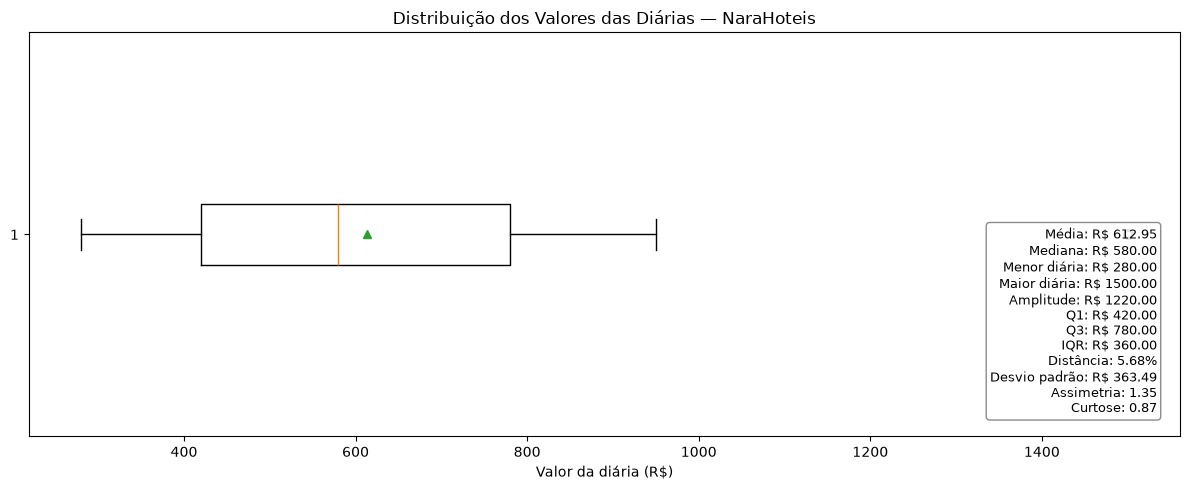

In [196]:
# Qual é o comportamento dos valores das diárias?

media_diaria = np.mean(df_analise['valor_diaria_base'])

mediana_diaria = np.median(df_analise['valor_diaria_base'])

menor_diaria = np.min(df_analise['valor_diaria_base'])

maior_diaria = np.max(df_analise['valor_diaria_base'])

amplitude = maior_diaria - menor_diaria

q1 = np.percentile(
    df_analise['valor_diaria_base'],
    25
)

q3 = np.percentile(
    df_analise['valor_diaria_base'],
    75
)

iqr = q3 - q1

distancia = (
    (media_diaria - mediana_diaria)
    / mediana_diaria
)

variancia_diaria = np.var(
    df_analise['valor_diaria_base']
)

desvio_padrao = np.std(
    df_analise['valor_diaria_base']
)

assimetria = df_analise['valor_diaria_base'].skew()

curtose = df_analise['valor_diaria_base'].kurt()


print(f"Média: R$ {media_diaria:.2f}")
print(f"Mediana: R$ {mediana_diaria:.2f}")
print(f"Menor diária: R$ {menor_diaria:.2f}")
print(f"Maior diária: R$ {maior_diaria:.2f}")
print(f"Amplitude: R$ {amplitude:.2f}")
print(f"Q1: R$ {q1:.2f}")
print(f"Q3: R$ {q3:.2f}")
print(f"IQR: R$ {iqr:.2f}")
print(f"Distância média-mediana: {distancia:.2%}")
print(f"Variância: {variancia_diaria:.2f}")
print(f"Desvio padrão: R$ {desvio_padrao:.2f}")
print(f"Assimetria: {assimetria:.2f}")
print(f"Curtose: {curtose:.2f}")

# Boxplot dos valores das diárias

texto = (
    f'Média: R$ {media_diaria:.2f}\n'
    f'Mediana: R$ {mediana_diaria:.2f}\n'
    f'Menor diária: R$ {menor_diaria:.2f}\n'
    f'Maior diária: R$ {maior_diaria:.2f}\n'
    f'Amplitude: R$ {amplitude:.2f}\n'
    f'Q1: R$ {q1:.2f}\n'
    f'Q3: R$ {q3:.2f}\n'
    f'IQR: R$ {iqr:.2f}\n'
    f'Distância: {distancia:.2%}\n'
    f'Desvio padrão: R$ {desvio_padrao:.2f}\n'
    f'Assimetria: {assimetria:.2f}\n'
    f'Curtose: {curtose:.2f}'
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.boxplot(
    df_analise['valor_diaria_base'],
    orientation="horizontal",
    showmeans=True
)

ax.set_title(
    'Distribuição dos Valores das Diárias — NaraHoteis'
)

ax.set_xlabel('Valor da diária (R$)')

# Caixa com as estatísticas
ax.text(
    0.98,
    0.05,
    texto,
    transform=ax.transAxes,
    fontsize=9,
    verticalalignment='bottom',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)

plt.tight_layout()

plt.show()

## 📊 Questão 1 — Comportamento dos valores das diárias

### 💰 Medidas de tendência central

| Indicador   |     Resultado |
| :---------- | ------------: |
| **Média**   | **R$ 612,95** |
| **Mediana** | **R$ 580,00** |

A média foi de **R$ 612,95**, enquanto a mediana foi de **R$ 580,00**.

---

### 📏AMPLITUDE - Dispersão dos valores

**R$ 280,00** → **R$ 1.500,00**

> **Amplitude = R$ 1.220,00**

Os valores das diárias variaram entre **R$ 280,00 e R$ 1.500,00**, indicando uma faixa de preços bastante ampla.

---

### 📦 Distribuição dos 50% centrais

**Q1 = R$ 420,00**    →    **Q3 = R$ 780,00**

> **IQR = R$ 360,00**

Isso significa que **50% dos valores centrais das diárias estão concentrados entre R$ 420,00 e R$ 780,00**.

---

### ↗️ Assimetria

> **Assimetria = 1,35**

A distribuição apresenta **assimetria positiva**, indicando uma cauda mais alongada em direção aos valores elevados.

---

### 🎯 Interpretação final

Como a distribuição apresenta **assimetria positiva**, os valores mais altos exercem maior influência sobre a média.

Por isso:

> **A mediana de R$ 580,00 é mais adequada para representar o valor típico da diária do que a média de R$ 612,95**, pois sofre


### Faturamento estimado por unidade

- Nós agrupamos o faturamento das reservas válidas por unidade e ordenamos de forma decrescente.


In [197]:
#faturamento por unidade
faturamento_unidade = (df_analise.groupby('nome_unidade')['faturamento'].sum().reset_index())

faturamento_unidade = faturamento_unidade.sort_values('faturamento',ascending=False)

display(faturamento_unidade)

,nome_unidade,faturamento
9,NaraHoteis Paraty,739380.0
6,NaraHoteis Mangaratiba,719110.0
8,NaraHoteis Nova Iguaçu Park,685520.0
12,NaraHoteis Teresópolis,682580.0
4,NaraHoteis Friburgo,677980.0
11,NaraHoteis Santa Teresa,676720.0
0,NaraHoteis Angra dos Reis,660290.0
1,NaraHoteis Barra da Tijuca,656340.0
5,NaraHoteis Ipanema,644560.0
10,NaraHoteis Petrópolis,641690.0


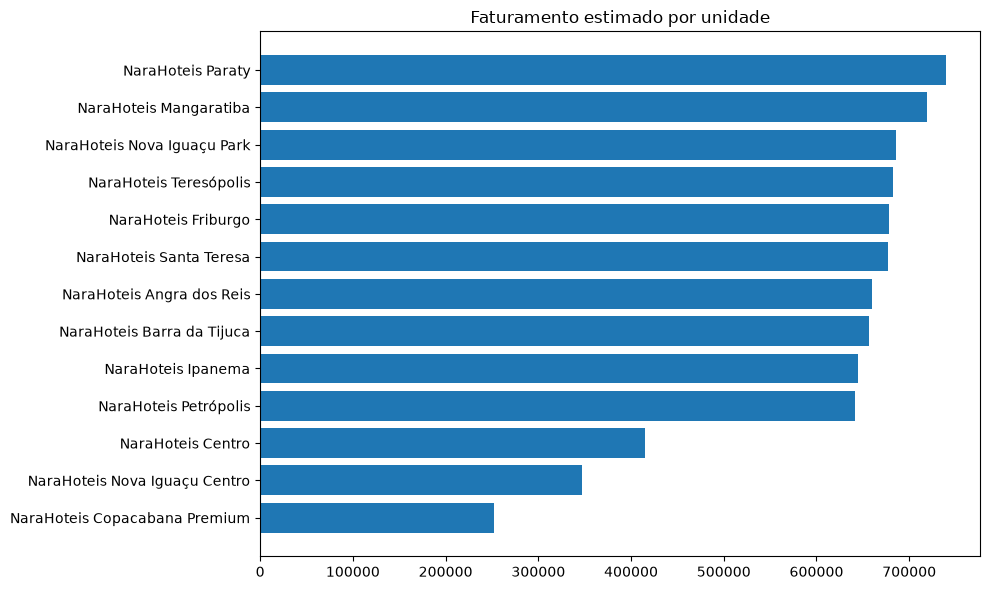

In [198]:
plt.figure(figsize=(10, 6))

plt.barh(faturamento_unidade['nome_unidade'],faturamento_unidade['faturamento'])


plt.title('Faturamento estimado por unidade')

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### 💰 Faturamento estimado por unidade

O faturamento estimado foi calculado para cada reserva válida pela relação:

> **Faturamento = quantidade de diárias × valor da diária-base**

Em seguida, os valores foram **agrupados por unidade** e somados para obter o faturamento estimado de cada hotel.

### 🏨 Resultado por unidade

| Unidade                | Faturamento estimado |
| :--------------------- | -------------------: |
| **Paraty**             |    **R$ 739.380,00** |
| **Mangaratiba**        |    **R$ 719.110,00** |
| **Nova Iguaçu Park**   |    **R$ 685.520,00** |
| Teresópolis            |        R$ 682.580,00 |
| Friburgo               |        R$ 677.980,00 |
| Santa Teresa           |        R$ 676.720,00 |
| Angra dos Reis         |        R$ 660.290,00 |
| Barra da Tijuca        |        R$ 656.340,00 |
| Ipanema                |        R$ 644.560,00 |
| Petrópolis             |        R$ 641.690,00 |
| Centro                 |        R$ 415.150,00 |
| Nova Iguaçu Centro     |        R$ 347.130,00 |
| **Copacabana Premium** |    **R$ 252.070,00** |

---

### 📊 Visão geral

* **Faturamento estimado da rede:** **R$ 7.798.520,00**
* **Reservas válidas:** **3.755**
* **Diárias vendidas:** **12.469**
* **Maior faturamento:** **Paraty — R$ 739.380,00**
* **Menor faturamento:** **Copacabana Premium — R$ 252.070,00**

> ⚠️ **Importante:** trata-se de uma **estimativa de receita bruta de hospedagem**, calculada a partir da diária-base. O valor não considera descontos, comissões de canais ou consumo de outros serviços do hotel.


---

# Questão 02 — Ocupação simultânea acima da capacidade

**O que se quer saber:** em algum momento alguma unidade teve mais quartos ocupados do que possui?

A verificação não pode ser feita contando reservas por mês, porque uma reserva ocupa o quarto em **todos os dias** entre o check-in e o check-out. Por isso a lógica adotada foi:

1. Para cada unidade, gerar todos os dias entre o primeiro check-in e o último check-out.
2. Para cada dia, contar quantas reservas estavam **em curso** (`data_checkin <= dia < data_checkout` — o dia do check-out não conta, pois o quarto é liberado).
3. Guardar o **pico** de ocupação simultânea e compará-lo com `num_quartos_total`.


In [199]:
# Transformar as colunas em datas

df_analise['data_checkin'] = pd.to_datetime(df_analise['data_checkin'])
df_analise['data_checkout'] = pd.to_datetime(df_analise['data_checkout'])


unidades = df_analise['id_unidade'].unique()

resultado = []


# Analisar cada unidade

for unidade in unidades:

    dados_unidade = df_analise[
        df_analise['id_unidade'] == unidade
    ]

    datas = pd.date_range(
        dados_unidade['data_checkin'].min(),
        dados_unidade['data_checkout'].max()
    )

    maior_ocupacao = 0
    datas_maior_ocupacao = []

    # Verificar a ocupação de cada dia

    for data in datas:

        reservas_ativas = (  ###identificar as reservas que estavam ativas naquele dia: o hóspede já entrou e ainda não saiu.
            (dados_unidade['data_checkin'] <= data) &
            (dados_unidade['data_checkout'] > data)
        )

        ocupacao = reservas_ativas.sum()

        if ocupacao > maior_ocupacao:
            maior_ocupacao = ocupacao
            datas_maior_ocupacao = [data]

        elif ocupacao == maior_ocupacao:
            datas_maior_ocupacao.append(data)

    nome_unidade = dados_unidade['nome_unidade'].iloc[0] #iloc[0] pega o primeiro valor da coluna
    capacidade = dados_unidade['num_quartos_total'].iloc[0]

    resultado.append([
        nome_unidade,
        capacidade,
        maior_ocupacao,
        datas_maior_ocupacao
    ])


# Criar tabela

capacidade = pd.DataFrame(
    resultado,
    columns=[
        'nome_unidade',
        'num_quartos_total',
        'maior_ocupacao',
        'datas_maior_ocupacao'
    ]
)

# Calcular excesso

capacidade['excesso'] = (
    capacidade['maior_ocupacao'] -
    capacidade['num_quartos_total']
)

# Mostrar somente as unidades acima da capacidade

acima_capacidade = capacidade[
    capacidade['excesso'] > 0
].copy()

# Percentual de excesso

acima_capacidade['percentual_excesso'] = (
    acima_capacidade['excesso'] /
    acima_capacidade['num_quartos_total'] * 100
).round(2)

acima_capacidade

,nome_unidade,num_quartos_total,maior_ocupacao,datas_maior_ocupacao,excesso,percentual_excesso
0,NaraHoteis Nova Iguaçu Centro,50,64,"[2024-06-15 00:00:00, 2024-06-16 00:00:00]",14,28.00
6,NaraHoteis Centro,60,79,"[2024-01-15 00:00:00, 2024-01-16 00:00:00]",19,31.67
12,NaraHoteis Copacabana Premium,40,45,"[2025-07-20 00:00:00, 2026-04-16 00:00:00]",5,12.50


In [200]:
acima_capacidade.style.format({
    'percentual_excesso': '{:.2f}%'
}).background_gradient(
    subset=['percentual_excesso'],
    cmap='RdPu'
).set_caption('Unidades acima da capacidade')

,nome_unidade,num_quartos_total,maior_ocupacao,datas_maior_ocupacao,excesso,percentual_excesso
0,NaraHoteis Nova Iguaçu Centro,50,64,"[Timestamp('2024-06-15 00:00:00'), Timestamp('2024-06-16 00:00:00')]",14,28.00%
6,NaraHoteis Centro,60,79,"[Timestamp('2024-01-15 00:00:00'), Timestamp('2024-01-16 00:00:00')]",19,31.67%
12,NaraHoteis Copacabana Premium,40,45,"[Timestamp('2025-07-20 00:00:00'), Timestamp('2026-04-16 00:00:00')]",5,12.50%


## 🏨 Questão 02 — Ocupação acima da capacidade

### 🔎 Resultado da análise

Foram identificadas **3 unidades** cujo pico de ocupação registrada ultrapassou a capacidade cadastrada:

| Unidade                | Capacidade | Pico de ocupação | Período do pico             | Excesso | Excesso (%) |
| :--------------------- | ---------: | ---------------: | :-------------------------- | ------: | ----------: |
| **Centro**             |         60 |           **79** | **15 e 16/01/2024**         | **+19** |  **31,67%** |
| **Nova Iguaçu Centro** |         50 |           **64** | **15 e 16/06/2024**         | **+14** |  **28,00%** |
| **Copacabana Premium** |         40 |           **45** | **20/07/2025 e 16/04/2026** |  **+5** |  **12,50%** |

### 📌 Interpretação

Os resultados indicam **ocupação registrada acima da capacidade** em três unidades.

Os maiores picos foram observados em períodos específicos:

* **Centro:** 79 reservas simultâneas para uma capacidade de 60 quartos;
* **Nova Iguaçu Centro:** 64 reservas simultâneas para uma capacidade de 50 quartos;
* **Copacabana Premium:** 45 reservas simultâneas para uma capacidade de 40 quartos.

Entretanto, esses resultados **não devem ser interpretados automaticamente como overbooking real**. Os registros precisam ser validados para verificar se os picos representam uma situação operacional real ou alguma inconsistência na base.

> **💡 Conclusão:** 3 unidades apresentaram registros de ocupação acima da capacidade cadastrada. O resultado representa um **sinal de alerta** e indica a necessidade de validar as reservas nos períodos identificados.

### ⚠️ Impactos potenciais para o negócio

Caso o excesso represente uma situação operacional real, pode resultar em:

* **Overbooking** e necessidade de realocação de hóspedes;
* **Problemas na experiência e satisfação dos clientes**;
* **Sobrecarga operacional** das equipes;
* **Risco de indisponibilidade de quartos**;
* Necessidade de **revisar a capacidade cadastrada e a qualidade dos dados**.




---

# Questão 03 — Unidades com faturamento discrepante

**O que se quer saber:** quais unidades têm faturamento estatisticamente fora do padrão da rede?

A técnica usada é o **critério do intervalo interquartílico (IQR)**, o mesmo do boxplot: considera-se discrepante toda unidade abaixo de Q1 − 1,5 × IQR ou acima de Q3 + 1,5 × IQR.




In [201]:
#Questão 3

faturamento = faturamento_unidade['faturamento']

q1 = np.percentile(faturamento, 25)

q3 = np.percentile(faturamento, 75)

iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr

limite_superior = q3 + 1.5 * iqr

print(f"Q1: R$ {q1:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

print(f"Q3: R$ {q3:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

print(f"IQR: R$ {iqr:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

print(f"Limite inferior: R$ {limite_inferior:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))

print(f"Limite superior: R$ {limite_superior:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))



Q1: R$ 641.690,00
Q3: R$ 682.580,00
IQR: R$ 40.890,00
Limite inferior: R$ 580.355,00
Limite superior: R$ 743.915,00


#### Resultados — limites de aceitação

| Medida | Valor |
|---|---|
| Q1 | R$ 641.690,00 |
| Q3 | R$ 682.580,00 |
| IQR | R$ 40.890,00 |
| Limite inferior | R$ 580.355,00 |
| Limite superior | R$ 743.915,00 |

O IQR é de apenas **R$ 40.890,00**, ou 6,8% da média da rede. Isso acontece porque dez das treze unidades estão concentradas em uma faixa muito estreita — o "miolo" da distribuição é quase uniforme, o que torna o critério bastante sensível a qualquer afastamento.


In [202]:
outliers = faturamento_unidade[
    (faturamento_unidade['faturamento'] < limite_inferior) |
    (faturamento_unidade['faturamento'] > limite_superior)]
outliers

,nome_unidade,faturamento
2,NaraHoteis Centro,415150.0
7,NaraHoteis Nova Iguaçu Centro,347130.0
3,NaraHoteis Copacabana Premium,252070.0


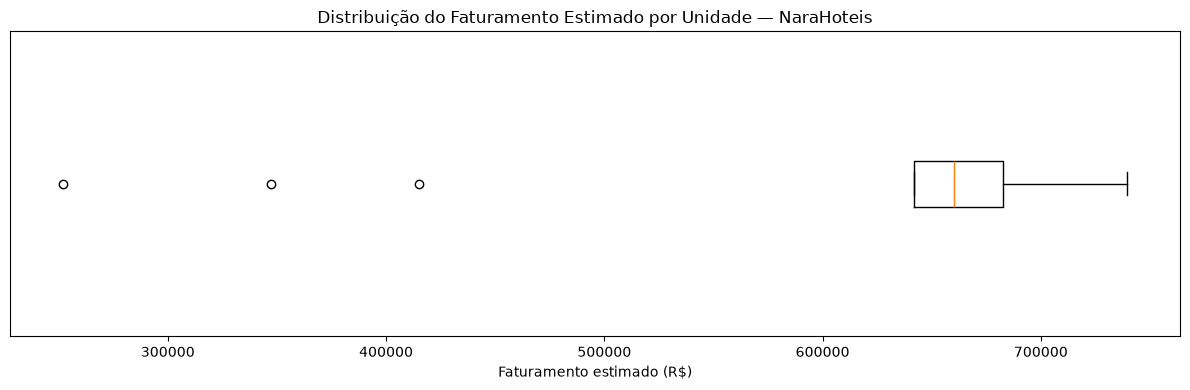

In [203]:
# Questão 3 — Boxplot

faturamento = faturamento_unidade['faturamento']

plt.figure(figsize=(12, 4))

plt.boxplot(
    faturamento,
    orientation='horizontal',
    whis=1.5,
    showfliers=True
)

plt.title('Distribuição do Faturamento Estimado por Unidade — NaraHoteis')

plt.xlabel('Faturamento estimado (R$)')

plt.yticks([])

plt.tight_layout()

plt.show()


## 💰 Questão 03 — Performance de receita

### 🔎 Resultado da análise

A análise do faturamento estimado identificou **3 unidades com valores discrepantes em relação às demais**, considerando os limites definidos pelo método do **IQR (Intervalo Interquartil)**.

| Unidade                | Faturamento estimado | Situação                  |
| :--------------------- | -------------------: | :------------------------ |
| **Centro**             |       **R$ 415.150** | Abaixo do limite inferior |
| **Nova Iguaçu Centro** |       **R$ 347.130** | Abaixo do limite inferior |
| **Copacabana Premium** |       **R$ 252.070** | Abaixo do limite inferior |

O **limite inferior** calculado foi de **R$ 580.355**. Não foram identificadas unidades acima do limite superior de **R$ 743.915**.

### 📌 Interpretação

As três unidades apresentaram faturamento estimado abaixo do padrão observado nas demais unidades.

* **Centro:** R$ 415.150
* **Nova Iguaçu Centro:** R$ 347.130
* **Copacabana Premium:** R$ 252.070

Esses valores foram classificados como **discrepantes estatisticamente**, mas isso **não significa necessariamente baixo desempenho**. A diferença pode estar relacionada às características de cada unidade, como capacidade, período de operação e quantidade de reservas.

### 🎯 Conclusão

> **Foram identificadas 3 unidades com receita discrepante: Centro, Nova Iguaçu Centro e Copacabana Premium. A análise indica que seus faturamentos estão abaixo do padrão das demais unidades, sendo necessário considerar as características de cada unidade antes de interpretar esses valores como desempenho inferior.**



---

# Questão 04 — Relação entre a avaliação dos hóspedes e o RevPAR

**O que se quer saber:** unidades mais bem avaliadas geram mais receita por quarto disponível?

O **RevPAR** (*Revenue per Available Room*) é o indicador padrão da hotelaria para comparar unidades de portes diferentes:

$$\text{RevPAR} = \frac{\text{faturamento}}{\text{nº de quartos} \times \text{dias do período}}$$

- Nós definimos o período de análise de 01/01/2023 a 31/08/2026, totalizando **1.339 dias**.
- Calculamos o RevPAR de cada unidade sobre esse período.
- Calculamos a avaliação média por unidade, considerando apenas reservas efetivamente avaliadas (`avaliado_sim_nao = 'Sim'`, nota maior que 0 e diferente de 99 — lembrando que **99 é o código de "não avaliado"**, e não uma nota).
- Medimos a **correlação de Pearson** entre as duas variáveis.


In [204]:
data_inicio = pd.Timestamp('2023-01-01')
data_fim = pd.Timestamp('2026-08-31')

dias_periodo = (data_fim - data_inicio).days + 1

dias_periodo

1339

In [205]:
resumo = (df_analise.groupby(['id_unidade','nome_unidade','num_quartos_total']).agg(faturamento=('faturamento', 'sum')).reset_index())
resumo['RevPAR'] = (
    resumo['faturamento'] /
    (
        resumo['num_quartos_total'] *
        dias_periodo
    )
)

In [206]:
avaliacoes = df_analise[
    (df_analise['avaliado_sim_nao'] == 'Sim') &
    (df_analise['avaliacao_hospede'] > 0) &
    (df_analise['avaliacao_hospede'] != 99)
]
media_avaliacao = (
    avaliacoes
    .groupby('id_unidade')['avaliacao_hospede']
    .mean()
    .reset_index()
)

media_avaliacao = media_avaliacao.rename(
    columns={
        'avaliacao_hospede': 'avaliacao_media'
    }
)

revpar_avaliacao = resumo.merge(
    media_avaliacao,
    on='id_unidade',
    how='inner'
)

display(revpar_avaliacao)

,id_unidade,nome_unidade,num_quartos_total,faturamento,RevPAR,avaliacao_media
0,1,NaraHoteis Ipanema,80,644560.0,6.017177,7.951417
1,2,NaraHoteis Barra da Tijuca,120,656340.0,4.084765,7.8159
2,3,NaraHoteis Centro,60,415150.0,5.167413,2.185185
3,4,NaraHoteis Santa Teresa,45,676720.0,11.230935,7.989399
4,5,NaraHoteis Nova Iguaçu Centro,50,347130.0,5.184914,2.166667
5,6,NaraHoteis Nova Iguaçu Park,55,685520.0,9.308439,7.865217
6,7,NaraHoteis Petrópolis,70,641690.0,6.846154,7.877729
7,8,NaraHoteis Teresópolis,60,682580.0,8.496141,7.876068
8,9,NaraHoteis Friburgo,55,677980.0,9.206056,7.884298
9,10,NaraHoteis Paraty,75,739380.0,7.362509,7.963563


#### Resultados — RevPAR e avaliação por unidade

| Unidade | RevPAR | Avaliação média |
|---|---|---|
| Santa Teresa | 11,23 | 7,99 |
| Mangaratiba | 10,74 | 7,76 |
| Nova Iguaçu Park | 9,31 | 7,87 |
| Friburgo | 9,21 | 7,88 |
| Teresópolis | 8,50 | 7,88 |
| Paraty | 7,36 | 7,96 |
| Petrópolis | 6,85 | 7,88 |
| Ipanema | 6,02 | 7,95 |
| Angra dos Reis | 5,48 | 7,80 |
| Nova Iguaçu Centro | 5,18 | 2,17 |
| Centro | 5,17 | 2,19 |
| Copacabana Premium | 4,71 | 6,98 |
| Barra da Tijuca | 4,08 | 7,82 |

Duas observações antes de olhar a correlação:

- **As avaliações não formam um contínuo.** Dez unidades estão entre 7,76 e 7,99 — uma faixa de 0,23 ponto —, Copacabana fica em 6,98 e duas unidades despencam para ~2,2. Não há nada entre 2,2 e 7,0. A variável se comporta como **dois grupos**, não como uma escala.
- **O RevPAR da Copacabana Premium está subestimado aqui.** O cálculo divide o faturamento por 1.339 dias para todas as unidades, mas a Copacabana só opera desde **janeiro de 2025** (574 dias). Corrigido o denominador, seu RevPAR passa de 4,71 para **10,98** — de última para segunda colocada. Esse é o tema da Questão 07.


In [207]:
r = np.corrcoef(
    revpar_avaliacao['avaliacao_media'],
    revpar_avaliacao['RevPAR']
)[0, 1]

print(f"Correlação de Pearson: {r:.3f}")

Correlação de Pearson: 0.426


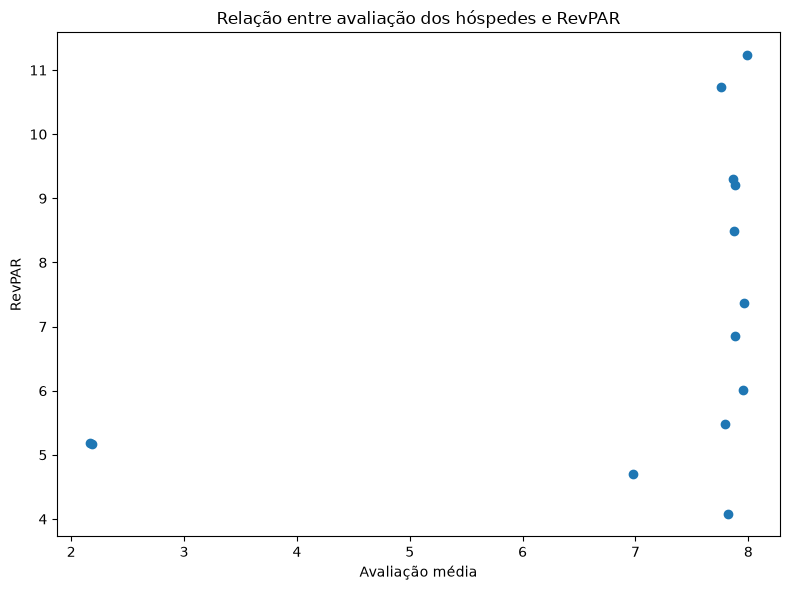

In [208]:
plt.figure(figsize=(8, 6))

plt.scatter(
    revpar_avaliacao['avaliacao_media'],
    revpar_avaliacao['RevPAR']
)

plt.xlabel('Avaliação média')
plt.ylabel('RevPAR')
plt.title('Relação entre avaliação dos hóspedes e RevPAR')

plt.tight_layout()
plt.show()

## ⭐ Questão 04 — Relação entre avaliação dos hóspedes e RevPAR

### 🔎 Resultado da análise

A análise buscou verificar se unidades com **melhores avaliações dos hóspedes** também apresentam **maior RevPAR**.

A correlação de Pearson encontrada foi:

> **r = 0,426**

Esse resultado indica uma **correlação positiva e moderada** entre avaliação média e RevPAR.

| Indicador                     |                          Resultado |
| :---------------------------- | ---------------------------------: |
| **Correlação de Pearson (r)** |                          **0,426** |
| **Número de unidades**        |                             **13** |
| **Interpretação**             | **Correlação positiva e moderada** |

### 📌 Interpretação

De forma geral, as unidades com avaliações mais altas tendem a apresentar RevPAR maior.

Entretanto, a relação **não é forte nem conclusiva**. A análise mostrou que:

* **10 unidades** possuem avaliações muito próximas, entre **7,76 e 7,99**;
* **Copacabana Premium** apresenta avaliação média de **6,98**;
* **Centro** e **Nova Iguaçu Centro** apresentam avaliações próximas de **2,2**.

Além disso, com apenas **13 unidades**, a correlação não apresentou significância estatística ao nível de 5% (**p ≈ 0,15**).

### 📊 Principais resultados

As maiores avaliações e RevPAR incluem:

* **Santa Teresa:** avaliação **7,99** | RevPAR **R$ 11,23**
* **Mangaratiba:** avaliação **7,76** | RevPAR **R$ 10,74**
* **Nova Iguaçu Park:** avaliação **7,87** | RevPAR **R$ 9,31**

Já as menores avaliações ocorreram em:

* **Centro:** avaliação **2,19** | RevPAR **R$ 5,17**
* **Nova Iguaçu Centro:** avaliação **2,17** | RevPAR **R$ 5,18**

### 🎯 Conclusão

> **Foi observada uma correlação positiva e moderada (r = 0,426) entre a avaliação dos hóspedes e o RevPAR.

### ⚠️ Observação metodológica

O RevPAR da **Copacabana Premium** está subestimado nessa questão porque foi calculado utilizando os **1.339 dias do período geral**, embora a unidade tenha iniciado sua operação em janeiro de 2025. A correção dessa questão é feita na **Questão 07**.




---

# Questão 05 — Previsão do RevPAR a partir da avaliação

**O que se quer saber:** é possível estimar o RevPAR de uma unidade a partir da nota média dos hóspedes?

A Questão 04 mediu a **força** da associação; esta questão tenta **modelá-la**, ajustando uma reta de regressão linear simples:

$$\text{RevPAR} = \beta_0 + \beta_1 \times \text{avaliação média}$$

- Nós ajustamos os coeficientes por mínimos quadrados (`np.polyfit`).
- Calculamos o **R²** como a proporção da variação do RevPAR explicada pelo modelo.

A regressão linear simples tenta encontrar uma relação matemática entre duas variáveis e usar essa relação para fazer estimativas.


In [209]:
# Questão 5 - Regressão Linear Simples

x = revpar_avaliacao['avaliacao_media']
y = revpar_avaliacao['RevPAR']
coeficiente = np.polyfit(x, y, 1)

b1 = coeficiente[0]
b0 = coeficiente[1]

print(f"Coeficiente angular: {b1:.2f}")
print(f"Intercepto: {b0:.2f}")
y_previsto = b0 + b1 * x

r2 = 1 - (
    np.sum((y - y_previsto) ** 2)
    / np.sum((y - np.mean(y)) ** 2)
)

print(f"R²: {r2:.2%}")

print(f"Equação da regressão: RevPAR = {b0:.2f} + {b1:.2f} × Avaliação")
print(f"R²: {r2:.2%}")

Coeficiente angular: 0.48
Intercepto: 3.92
R²: 18.18%
Equação da regressão: RevPAR = 3.92 + 0.48 × Avaliação
R²: 18.18%


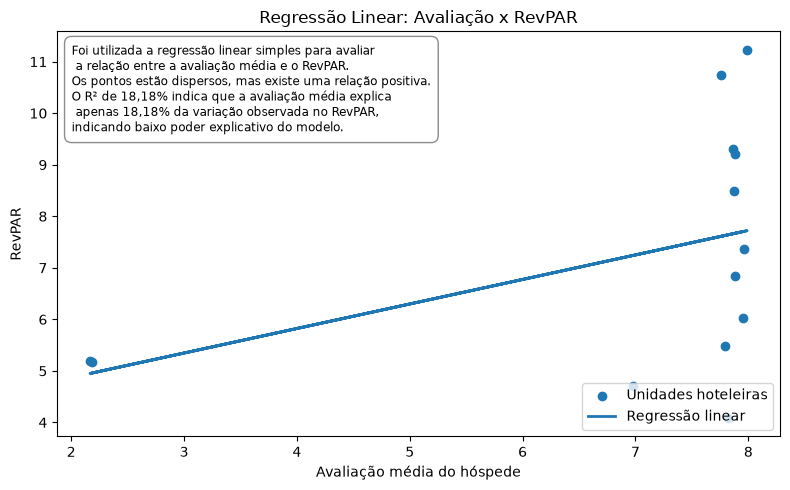

In [210]:
plt.figure(figsize=(8, 5))

plt.scatter(
    x,
    y,
    label='Unidades hoteleiras'
)

plt.plot(
    x,
    y_previsto,
    linewidth=2,
    label='Regressão linear'
)

plt.xlabel('Avaliação média do hóspede')
plt.ylabel('RevPAR')

plt.title('Regressão Linear: Avaliação x RevPAR')

plt.legend(
    loc='lower right'
)

plt.text(
    0.02, 0.97,
    'Foi utilizada a regressão linear simples para avaliar \n a relação entre a avaliação média e o RevPAR.\n'
    'Os pontos estão dispersos, mas existe uma relação positiva.\n'
    'O R² de 18,18% indica que a avaliação média explica \n apenas 18,18% da variação observada no RevPAR,\n'
    'indicando baixo poder explicativo do modelo.',
    transform=plt.gca().transAxes,
    fontsize=8.5,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(
        boxstyle='round,pad=0.6',
        facecolor='white',
        edgecolor='gray',
        alpha=0.9
    )
)

plt.tight_layout()

plt.show()

A regressão linear simples apresentou coeficiente angular de 0,48 e intercepto de 3,92, resultando na equação RevPAR = 3,92 + 0,48 × avaliação média. O coeficiente de determinação (R²) foi de 18,18%, indicando que a avaliação média explica uma parcela limitada da variação observada no RevPAR. Dessa forma, a avaliação dos hóspedes, isoladamente, possui capacidade explicativa limitada para estimar o RevPAR, sendo necessário considerar outras variáveis para uma análise preditiva mais abrangente.

## Conclusão — Questão 05

Existe uma associação positiva entre avaliação e RevPAR, mas a avaliação sozinha não explica bem o RevPAR. O gráfico mostra muita dispersão dos pontos e o R² de 18,18% confirma isso.


---

# Questão 06 — Variabilidade do faturamento entre as regiões

**O que se quer saber:** em qual região o faturamento das unidades é mais homogêneo, e em qual é mais desigual?

- Nós associamos cada unidade à sua região e padronizamos a grafia do campo.
- Calculamos **média, variância e desvio padrão** do faturamento dentro de cada região.


In [211]:
# Questão 6 - Variabilidade do faturamento por região

faturamento_regiao = faturamento_unidade.merge(
    df_unidades[['nome_unidade', 'regiao']],
    on='nome_unidade',
    how='left'
)

# Padronização dos nomes das regiões
faturamento_regiao['regiao'] = (
    faturamento_regiao['regiao']
    .str.strip()
    .str.title()
)

# Cálculo da média, variância e desvio padrão
variabilidade = (
    faturamento_regiao
    .groupby('regiao')['faturamento']
    .agg(
        media='mean',
        variancia='var',
        desvio_padrao=lambda x: x.std()
    )
    .reset_index()
)

# Formatação dos valores em reais
variabilidade_formatada = variabilidade.copy()

for coluna in ['media', 'variancia', 'desvio_padrao']:
    variabilidade_formatada[coluna] = (
        variabilidade_formatada[coluna]
        .apply(lambda x: f'R$ {x:,.2f}'
               .replace(',', 'X')
               .replace('.', ',')
               .replace('X', '.'))
    )

display(variabilidade_formatada)

,regiao,media,variancia,desvio_padrao
0,Baixada Fluminense,"R$ 516.325,00","R$ 57.253.896.050,00","R$ 239.277,86"
1,Capital,"R$ 528.968,00","R$ 35.260.707.470,00","R$ 187.778,35"
2,Costa Verde,"R$ 706.260,00","R$ 1.687.648.900,00","R$ 41.081,00"
3,Serra,"R$ 667.416,67","R$ 501.686.033,33","R$ 22.398,35"


### Resultado — Variabilidade do faturamento por região

A **Baixada Fluminense** apresenta a maior variabilidade no faturamento, com **desvio padrão de aproximadamente R$ 169,2 mil**, seguida pela **Capital**, com R$ 167,9 mil.

Esse resultado indica que o faturamento das unidades da Baixada Fluminense apresenta maior dispersão em relação à média regional, sugerindo **maior heterogeneidade no desempenho comercial entre as unidades**.

Para a gestão comercial, essa variabilidade pode indicar a necessidade de investigar quais unidades apresentam faturamento muito acima ou abaixo do padrão regional, identificando possíveis diferenças relacionadas à ocupação, preços praticados, perfil dos clientes ou desempenho das vendas.

Já a **Serra** apresenta a menor variabilidade, com desvio padrão de aproximadamente **R$ 18,3 mil**, indicando maior homogeneidade entre suas unidades.

> **Conclusão:** a Baixada Fluminense é a região que apresenta a maior variabilidade absoluta no faturamento, enquanto a Serra apresenta o comportamento mais homogêneo. A identificação das unidades responsáveis pela maior dispersão pode auxiliar na definição de estratégias comerciais específicas.

---

# Questão 07 — O caso da unidade Copacabana Premium

A NaraHoteis Copacabana Premium é a unidade com a **menor receita da rede**. A diretoria quer saber se esse número, isoladamente, permite concluir que a unidade tem desempenho ruim.

Nesta questão serão analisados:

- a receita estimada de cada unidade da rede;
- a posição da Copacabana Premium frente à média da rede;
- a comparação com as demais unidades **5 estrelas**, corrigindo o porte e o tempo de operação.

**Base de cálculo:** apenas reservas válidas — `status_reserva` igual a `Confirmada` ou `Concluída` (3.755 das 4.649 reservas) —, com `receita = qtd_diarias × valor_diaria_base`.


### Receita estimada por unidade

- Nós associamos a diária-base de cada tipo de quarto às reservas válidas.
- Convertemos `qtd_diarias` e `valor_diaria_base` para valores numéricos antes do cálculo.
- Consolidamos receita, número de reservas e total de diárias por unidade.
- Normalizamos pela capacidade instalada (`receita_por_quarto`) e medimos a distância de cada unidade em relação à média da rede.


In [212]:
# Associar a diária-base ao tipo de quarto
reservas_receita = reservas_validas.merge(
    df_quartos[["id_tipo_quarto", "valor_diaria_base"]],
    on="id_tipo_quarto",
    how="left"
)

reservas_receita["qtd_diarias"] = pd.to_numeric(
    reservas_receita["qtd_diarias"], errors="coerce"
)

reservas_receita["valor_diaria_base"] = pd.to_numeric(
    reservas_receita["valor_diaria_base"], errors="coerce"
)

# Receita estimada
reservas_receita["receita"] = (
    reservas_receita["qtd_diarias"] *
    reservas_receita["valor_diaria_base"]
)

# Consolidar por unidade
receita_unidade = reservas_receita.groupby("id_unidade").agg(
    receita_total=("receita", "sum"),
    numero_reservas=("id_reserva", "count"),
    total_diarias=("qtd_diarias", "sum")
).reset_index()

# Adicionar informações da unidade
receita_unidade = receita_unidade.merge(
    df_unidades[
        ["id_unidade", "nome_unidade", "categoria_hotel", "num_quartos_total"]
    ],
    on="id_unidade",
    how="left"
)

# Receita por quarto
receita_unidade["receita_por_quarto"] = np.where(
    receita_unidade["num_quartos_total"] > 0,
    receita_unidade["receita_total"] /
    receita_unidade["num_quartos_total"],
    np.nan
)

# num_quartos_total é Int64 (nullable); convertemos para float para os cálculos abaixo
receita_unidade["num_quartos_total"] = receita_unidade["num_quartos_total"].astype(float)

media_rede_receita_quarto = receita_unidade["receita_por_quarto"].mean()

receita_unidade["diferenca_media_%"] = np.where(
    media_rede_receita_quarto > 0,
    (
        (receita_unidade["receita_por_quarto"] - media_rede_receita_quarto)
        / media_rede_receita_quarto
    ) * 100,
    np.nan
)

receita_unidade.sort_values("receita_total", ascending=False)

,id_unidade,receita_total,numero_reservas,total_diarias,nome_unidade,categoria_hotel,num_quartos_total,receita_por_quarto,diferenca_media_%
9,10,739380.0,295,1081.0,NaraHoteis Paraty,5 estrelas,75.0,9858.400000,2.005389
11,12,719110.0,299,1051.0,NaraHoteis Mangaratiba,4 Estrelas,50.0,14382.200000,48.813388
5,6,685520.0,275,980.0,NaraHoteis Nova Iguaçu Park,3 estrelas,55.0,12464.000000,28.965670
7,8,682580.0,282,999.0,NaraHoteis Teresópolis,4 Estrelas,60.0,11376.333333,17.711526
8,9,677980.0,287,1031.0,NaraHoteis Friburgo,4 Estrelas,55.0,12326.909091,27.547183
3,4,676720.0,320,1105.0,NaraHoteis Santa Teresa,4 Estrelas,45.0,15038.222222,55.601285
10,11,660290.0,276,968.0,NaraHoteis Angra dos Reis,5 Estrelas,90.0,7336.555556,-24.088270
1,2,656340.0,283,1013.0,NaraHoteis Barra da Tijuca,4 Estrelas,120.0,5469.500000,-43.406793
0,1,644560.0,293,1021.0,NaraHoteis Ipanema,5 estrelas,80.0,8057.000000,-16.633793
6,7,641690.0,271,1008.0,NaraHoteis Petrópolis,5 estrelas,70.0,9167.000000,-5.148564


#### Resultados — receita por unidade

A rede somou **R$ 7.798.520,00** em receita estimada, com média de **R$ 599.886,15** por unidade e distribuição bastante desigual entre as 13 unidades.

| Posição | Unidade | Receita estimada | Quartos | Receita/quarto | vs. média |
|---|---|---|---|---|---|
| 1º | Paraty | R$ 739.380,00 | 75 | R$ 9.858,40 | +2,0% |
| 2º | Mangaratiba | R$ 719.110,00 | 50 | R$ 14.382,20 | +48,8% |
| 3º | Nova Iguaçu Park | R$ 685.520,00 | 55 | R$ 12.464,00 | +29,0% |
| 4º | Teresópolis | R$ 682.580,00 | 60 | R$ 11.376,33 | +17,7% |
| 5º | Friburgo | R$ 677.980,00 | 55 | R$ 12.326,91 | +27,5% |
| 6º | Santa Teresa | R$ 676.720,00 | 45 | R$ 15.038,22 | +55,6% |
| 7º | Angra dos Reis | R$ 660.290,00 | 90 | R$ 7.336,56 | −24,1% |
| 8º | Barra da Tijuca | R$ 656.340,00 | 120 | R$ 5.469,50 | −43,4% |
| 9º | Ipanema | R$ 644.560,00 | 80 | R$ 8.057,00 | −16,6% |
| 10º | Petrópolis | R$ 641.690,00 | 70 | R$ 9.167,00 | −5,1% |
| 11º | Centro | R$ 415.150,00 | 60 | R$ 6.919,17 | −28,4% |
| 12º | Nova Iguaçu Centro | R$ 347.130,00 | 50 | R$ 6.942,60 | −28,2% |
| 13º | **Copacabana Premium** | **R$ 252.070,00** | 40 | **R$ 6.301,75** | **−34,8%** |

Três leituras se destacam:

- **Dez unidades formam um bloco homogêneo**, entre R$ 641.690,00 e R$ 739.380,00 — uma diferença de apenas 15% entre a primeira e a décima colocada.
- **Três unidades ficam fora desse bloco:** Centro, Nova Iguaçu Centro e Copacabana Premium.
- A **média de receita por quarto é de R$ 9.664,59**, e o ranking muda completamente quando a capacidade entra na conta.

O caso da **Barra da Tijuca** já mostra por que a receita total engana: ela tem a 8ª maior receita da rede, mas, com **120 quartos**, registra a **pior receita por quarto** de todas (−43,4%). Já **Santa Teresa**, apenas a 6ª em receita, lidera em receita por quarto com 45 quartos. O porte precisa entrar na conta antes de qualquer julgamento.

### Destaque numérico — Copacabana Premium

- Nós isolamos os indicadores da unidade para comparar diretamente com a média da rede.

In [213]:
# Destaque numérico da Copacabana Premium

ID_COPACABANA = df_unidades.loc[df_unidades["nome_unidade"].str.contains("Copacabana Premium", case=False, na=False),"id_unidade"].iloc[0]

cop_receita = receita_unidade[receita_unidade["id_unidade"].eq(ID_COPACABANA)].iloc[0]

print(f"Receita estimada — Copacabana Premium: R$ {cop_receita['receita_total']:,.2f}")
print(f"Receita por quarto — Copacabana Premium: R$ {cop_receita['receita_por_quarto']:,.2f}")
print(f"Média da rede por quarto: R$ {media_rede_receita_quarto:,.2f}")
print(f"Diferença contra a média da rede: {cop_receita['diferenca_media_%']:.1f}%")

Receita estimada — Copacabana Premium: R$ 252,070.00
Receita por quarto — Copacabana Premium: R$ 6,301.75
Média da rede por quarto: R$ 9,664.59
Diferença contra a média da rede: -34.8%


#### Resultados — Copacabana Premium

| Indicador | Copacabana Premium | Demais unidades |
|---|---|---|
| Receita estimada | R$ 252.070,00 | R$ 347.130,00 a R$ 739.380,00 |
| Receita por quarto | R$ 6.301,75 | média de R$ 9.664,59 |
| Diferença contra a média | **−34,8%** | — |
| Quartos | 40 (menor da rede) | 45 a 120 |
| Reservas válidas | 112 | 271 a 410 (média de 304) |
| Diárias vendidas | 315 | 872 a 1.105 (média de 1.013) |

A diferença **não vem do preço praticado**: a unidade vendeu **315 diárias** contra uma média de **1.013** nas demais, ou seja, **cerca de 31% do volume** da rede. O gargalo aparente é de **volume acumulado**, o que obriga a verificar há quanto tempo cada unidade opera antes de concluir qualquer coisa.

### Receita estimada por unidade — visualização

Nós ordenamos as unidades pela receita estimada e marcamos a média da rede com uma linha de referência.

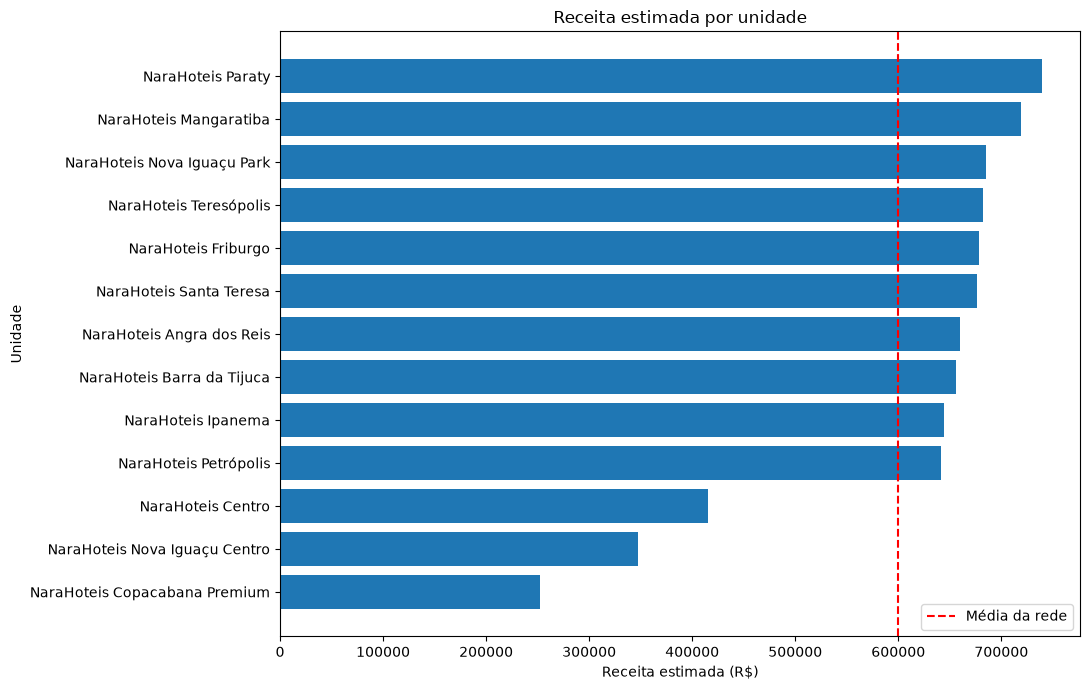

In [214]:
# Gráfico em matplotlib puro (o seaborn não estava importado e nenhuma outra célula o usa)
grafico_receita = receita_unidade.sort_values("receita_total", ascending=True).copy()

plt.figure(figsize=(11, 7))

plt.barh(grafico_receita["nome_unidade"],grafico_receita["receita_total"])

plt.axvline(receita_unidade["receita_total"].mean(),color="red", linestyle="--", label="Média da rede")

plt.title("Receita estimada por unidade")
plt.xlabel("Receita estimada (R$)")
plt.ylabel("Unidade")
plt.legend()

plt.tight_layout()
plt.show()

#### Leitura do gráfico

O gráfico confirma a leitura numérica: há um **patamar dominante** com dez unidades muito próximas entre si e uma **cauda inferior** formada por Centro, Nova Iguaçu Centro e Copacabana Premium, as três abaixo da linha da média da rede (R$ 599.886,15).

O gráfico, porém, compara unidades com **capacidades e períodos de operação diferentes**. Ele responde "quem faturou mais", não "quem opera melhor".

### Métricas complementares — corrigindo porte e tempo de operação

- Nós calculamos a **janela de operação** de cada unidade (do primeiro check-in ao último check-out registrado).
- Calculamos o **RevPAR** (receita por quarto disponível por dia), que corrige simultaneamente o porte e o tempo de operação, e a **diária média** efetiva.
- Recalculamos a avaliação dos hóspedes **excluindo o código 99**, que na base marca reservas não avaliadas (`avaliado_sim_nao = 'Não'`) e contamina qualquer média calculada sem tratamento.

In [215]:
# Métricas complementares — normalização por porte, por tempo de operação e limpeza da avaliação

janela = reservas_validas.groupby("id_unidade").agg(primeiro_checkin=("data_checkin", "min"), ultimo_checkout=("data_checkout", "max")).reset_index()

metricas = receita_unidade.merge(janela, on="id_unidade", how="left")

metricas["dias_operacao"] = (metricas["ultimo_checkout"] - metricas["primeiro_checkin"]).dt.days

metricas["RevPAR"] = (metricas["receita_total"] /(metricas["num_quartos_total"] * metricas["dias_operacao"]))

metricas["diaria_media"] = (metricas["receita_total"] / metricas["total_diarias"])

# O código 99 marca reservas não avaliadas e precisa sair do cálculo da média
avaliacoes_validas = reservas_validas[reservas_validas["avaliacao_hospede"] <= 10]

media_avaliacao = avaliacoes_validas.groupby("id_unidade").agg(avaliacao_media_limpa=("avaliacao_hospede", "mean"),qtd_avaliacoes=("avaliacao_hospede", "count")).reset_index()

metricas = metricas.merge(media_avaliacao, on="id_unidade", how="left")

print(
    metricas[[
        "nome_unidade",
        "categoria_hotel",
        "dias_operacao",
        "RevPAR",
        "diaria_media",
        "receita_por_quarto",
        "avaliacao_media_limpa",
        "qtd_avaliacoes"
    ]].sort_values("RevPAR", ascending=False).round(2).to_string(index=False))

print("\nMédia de RevPAR da rede:", round(metricas["RevPAR"].mean(), 2))
print("Diária média da rede: R$", round(metricas["receita_total"].sum() / metricas["total_diarias"].sum(), 2))


                 nome_unidade categoria_hotel  dias_operacao  RevPAR  diaria_media  receita_por_quarto  avaliacao_media_limpa  qtd_avaliacoes
      NaraHoteis Santa Teresa      4 Estrelas           1334   11.27        612.42            15038.22                   7.99             283
NaraHoteis Copacabana Premium      5 estrelas            574   10.98        800.22             6301.75                   6.98              99
       NaraHoteis Mangaratiba      4 Estrelas           1338   10.75        684.22            14382.20                   7.73             263
  NaraHoteis Nova Iguaçu Park      3 estrelas           1326    9.40        699.51            12464.00                   7.87             230
          NaraHoteis Friburgo      4 Estrelas           1330    9.27        657.59            12326.91                   7.88             242
       NaraHoteis Teresópolis      4 Estrelas           1339    8.50        683.26            11376.33                   7.88             234
      

#### Resultados — o ranking se inverte

| Unidade | Dias de operação | RevPAR | Diária média | Avaliação (limpa) |
|---|---|---|---|---|
| Santa Teresa | 1.334 | 11,27 | R$ 612,42 | 7,99 |
| **Copacabana Premium** | **574** | **10,98** | **R$ 800,22** | 6,98 |
| Mangaratiba | 1.338 | 10,75 | R$ 684,22 | 7,73 |
| Nova Iguaçu Park | 1.326 | 9,40 | R$ 699,51 | 7,87 |
| Friburgo | 1.330 | 9,27 | R$ 657,59 | 7,88 |
| Teresópolis | 1.339 | 8,50 | R$ 683,26 | 7,88 |
| Paraty | 1.340 | 7,36 | R$ 683,98 | 7,96 |
| Petrópolis | 1.338 | 6,85 | R$ 636,60 | 7,81 |
| Ipanema | 1.327 | 6,07 | R$ 631,30 | 7,95 |
| Angra dos Reis | 1.328 | 5,52 | R$ 682,12 | 7,80 |
| Nova Iguaçu Centro | 1.309 | 5,30 | R$ 398,08 | 2,17 |
| Centro | 1.334 | 5,19 | R$ 405,02 | 2,18 |
| Barra da Tijuca | 1.329 | 4,12 | R$ 647,92 | 7,82 |

Três achados:

1. **A Copacabana Premium opera há menos da metade do tempo.** O primeiro check-in registrado é de **24/01/2025**, enquanto todas as outras doze unidades começam em **janeiro de 2023**. São **574 dias** de janela contra 1.309 a 1.340 das demais — aproximadamente **43% do período** coberto pela base. A comparação por receita acumulada nunca foi justa.
2. **Corrigido o tempo, ela sobe para o 2º lugar da rede em RevPAR** (10,98), atrás apenas de Santa Teresa (11,27) e **41,9% acima da média da rede** (7,74).
3. **Ela tem a maior diária média da rede: R$ 800,22**, contra R$ 625,43 da rede. Isso é explicado pelo mix de produto — a unidade só vende categorias de alto valor (Suíte Master Copacabana, Cobertura Presidencial e Suíte Vista Mar), sem quartos Standard ou Superior.

A avaliação corrigida também muda o diagnóstico da rede: **Centro (2,18) e Nova Iguaçu Centro (2,17)** são as duas unidades com problema real de satisfação — as demais ficam entre 6,98 e 7,99. Sem excluir o código 99, essas médias apareciam invertidas e sem sentido.


### Comparação entre as unidades 5 estrelas

- Nós padronizamos o campo `categoria_hotel` (havia variações como `5 estrelas` e `5 Estrelas`) antes de filtrar.
- Comparamos a Copacabana Premium apenas com unidades da mesma categoria, para isolar o efeito do padrão do hotel.

In [216]:
# Métricas complementares — normalização por porte, por tempo de operação e limpeza da avaliação

janela = reservas_validas.groupby("id_unidade").agg(primeiro_checkin=("data_checkin", "min"),ultimo_checkout=("data_checkout", "max")).reset_index()

metricas = receita_unidade.merge(janela, on="id_unidade", how="left")

metricas["dias_operacao"] = (metricas["ultimo_checkout"] - metricas["primeiro_checkin"]).dt.days

metricas["RevPAR"] = (metricas["receita_total"] /(metricas["num_quartos_total"] * metricas["dias_operacao"]))

metricas["diaria_media"] = (metricas["receita_total"] / metricas["total_diarias"])

# O código 99 marca reservas não avaliadas e precisa sair do cálculo da média
avaliacoes_validas = reservas_validas[reservas_validas["avaliacao_hospede"] <= 10]

media_avaliacao = avaliacoes_validas.groupby("id_unidade").agg(avaliacao_media_limpa=("avaliacao_hospede", "mean"),qtd_avaliacoes=("avaliacao_hospede", "count")).reset_index()

metricas = metricas.merge(media_avaliacao, on="id_unidade", how="left")

print(
    metricas[[
        "nome_unidade",
        "categoria_hotel",
        "dias_operacao",
        "RevPAR",
        "diaria_media",
        "receita_por_quarto",
        "avaliacao_media_limpa",
        "qtd_avaliacoes"
    ]].sort_values("RevPAR", ascending=False).round(2).to_string(index=False)
)

print("\nMédia de RevPAR da rede:", round(metricas["RevPAR"].mean(), 2))
print("Diária média da rede: R$", round(metricas["receita_total"].sum() / metricas["total_diarias"].sum(), 2))

                 nome_unidade categoria_hotel  dias_operacao  RevPAR  diaria_media  receita_por_quarto  avaliacao_media_limpa  qtd_avaliacoes
      NaraHoteis Santa Teresa      4 Estrelas           1334   11.27        612.42            15038.22                   7.99             283
NaraHoteis Copacabana Premium      5 estrelas            574   10.98        800.22             6301.75                   6.98              99
       NaraHoteis Mangaratiba      4 Estrelas           1338   10.75        684.22            14382.20                   7.73             263
  NaraHoteis Nova Iguaçu Park      3 estrelas           1326    9.40        699.51            12464.00                   7.87             230
          NaraHoteis Friburgo      4 Estrelas           1330    9.27        657.59            12326.91                   7.88             242
       NaraHoteis Teresópolis      4 Estrelas           1339    8.50        683.26            11376.33                   7.88             234
      

#### Resultados — comparação entre pares

| Unidade 5 estrelas | RevPAR | Diária média | Receita/quarto | Quartos | Dias |
|---|---|---|---|---|---|
| **Copacabana Premium** | **10,98** | **R$ 800,22** | R$ 6.301,75 | 40 | 574 |
| Paraty | 7,36 | R$ 683,98 | R$ 9.858,40 | 75 | 1.340 |
| Petrópolis | 6,85 | R$ 636,60 | R$ 9.167,00 | 70 | 1.338 |
| Ipanema | 6,07 | R$ 631,30 | R$ 8.057,00 | 80 | 1.327 |
| Angra dos Reis | 5,52 | R$ 682,12 | R$ 7.336,56 | 90 | 1.328 |

Entre os seus pares diretos, a unidade com a **menor receita da rede** tem o **maior RevPAR** e a **maior diária média** — 49% acima do segundo colocado em RevPAR (Paraty). A última posição no ranking de receita e a primeira posição no ranking de eficiência descrevem a mesma unidade.

## Conclusão analítica — Questão 07

A NaraHoteis Copacabana Premium é, de fato, a **última colocada em receita estimada (R$ 252.070,00)** e está **34,8% abaixo da média da rede em receita por quarto (R$ 6.301,75 contra R$ 9.664,59)**. Esses dois números, no entanto, **não sustentam um diagnóstico de baixo desempenho**, porque comparam uma unidade pequena e recém-inaugurada com unidades maiores que operam desde o início da base.

Normalizados os indicadores por **capacidade** e por **tempo de operação**, o resultado se inverte:

- **RevPAR de 10,98** — o **maior entre as unidades 5 estrelas** e o **2º maior da rede**, atrás apenas de Santa Teresa (11,27);
- **41,9% acima da média de RevPAR da rede** (7,74);
- **diária média de R$ 800,22**, a **mais alta da rede** (média geral de R$ 625,43);
- **574 dias de operação** — primeiro check-in em **24/01/2025** — contra 1.309 a 1.340 dias das demais unidades, todas ativas desde janeiro de 2023;
- **40 quartos**, a menor capacidade instalada da rede.

Mantido o ritmo atual de vendas ao longo de uma janela equivalente à das demais unidades (1.340 dias), a receita projetada seria de aproximadamente **R$ 588 mil**, o que corresponderia a cerca de **R$ 14,7 mil por quarto** — colocando a unidade **em segundo lugar na rede**, e não em último. É uma simulação sob hipótese de ritmo constante, mas suficiente para mostrar que a posição atual no ranking é um efeito do tempo de operação, não da operação em si.

O desempenho recente reforça essa leitura: a unidade fez **R$ 130.420,00 em 2025** (58 reservas) e já acumula **R$ 121.650,00 em 2026** (54 reservas) com o ano ainda em curso na base — ritmo estável ou levemente superior. Somam-se a isso **2 dias de operação acima da capacidade**, com pico de **112,5% de ocupação** (Questão 02), sinal de demanda pressionando uma capacidade instalada pequena.

### Pontos de atenção reais

Nem tudo aponta na mesma direção, e dois pontos merecem acompanhamento:

- **Satisfação.** Com a avaliação corrigida (excluindo o código 99), a unidade marca **6,98**, a **menor entre os cinco hotéis 5 estrelas** (os outros ficam entre 7,80 e 7,96). A base é pequena — apenas **99 avaliações válidas** —, mas a diferença é consistente e merece investigação, sobretudo em uma unidade que cobra a diária mais alta da rede.
- **Estadia curta.** A média é de **2,8 diárias por reserva**, contra 3,3 na rede. É um padrão compatível com hotelaria urbana de alto valor, mas pressiona custos de governança e check-in por diária vendida.

### Principais achados

- **Receita total:** última da rede — efeito de porte reduzido e de operação recente, não de baixa performance.
- **Receita por quarto:** −34,8% contra a média — indicador ainda contaminado pelo tempo de operação.
- **RevPAR:** 10,98 — 1º lugar entre os 5 estrelas, 2º lugar na rede, +41,9% contra a média.
- **Diária média:** R$ 800,22 — a maior da rede, sustentada por um mix exclusivo de suítes e cobertura.
- **Avaliação limpa:** 6,98 — o único indicador em que a unidade fica atrás dos seus pares.

### Ressalvas metodológicas

- A receita é **estimada** por `qtd_diarias × valor_diaria_base`; não considera descontos, tarifas promocionais, comissões de canal (8% a 18% conforme `canaislimpo.csv`) nem receitas acessórias. A Copacabana Premium, com diária média mais alta, também tende a ter comissão absoluta maior por reserva.
- A janela de operação foi aproximada pelo **primeiro check-in e último check-out** de cada unidade, e não pela data efetiva de inauguração.
- Os níveis absolutos de RevPAR (entre 4 e 11) e de ocupação (entre 0,6% e 1,8%) são baixos porque a base contém uma **amostra de reservas**, não o histórico completo. Os indicadores valem como **índice comparativo entre unidades**, não como medida operacional real.
- O valor **99 em `avaliacao_hospede` é um código de "não avaliado"** (todos os 505 registros com 99 têm `avaliado_sim_nao = 'Não'`), e não uma nota. Toda média de avaliação no projeto precisa filtrar esse código — inclusive a da Questão 04, que foi calculada sem esse tratamento.

> **Conclusão:** a receita total, isoladamente, classifica incorretamente a Copacabana Premium como a pior unidade da rede. Corrigindo por capacidade e por tempo de operação, ela é uma das unidades **mais eficientes** da NaraHoteis. A recomendação é acompanhá-la por **RevPAR e diária média**, tratar a avaliação de 6,98 como ponto de atenção específico e só reavaliar sua posição no ranking geral após um ciclo de operação comparável ao das demais.


---

# Questão 08 — Evolução anual do faturamento

**O que se quer saber:** o faturamento da rede está crescendo ou caindo ao longo dos anos?

Há um cuidado metodológico decisivo aqui: a base termina em **agosto de 2026**. Comparar o ano de 2026 completo com os anos anteriores produziria uma queda falsa, causada apenas pelos quatro meses ausentes.

- Nós extraímos ano e mês da data de check-in.
- Filtramos **apenas os meses de janeiro a agosto** de cada ano, garantindo períodos comparáveis.
- Somamos o faturamento por ano e calculamos a variação percentual encadeada.


In [217]:
#Questão 8
df_analise['ano'] = (
    df_analise['data_checkin'].dt.year
)

df_analise['mes'] = (
    df_analise['data_checkin'].dt.month
)

jan_ago = df_analise[
    df_analise['mes'] <= 8
]

evolucao = (
    jan_ago
    .groupby('ano')['faturamento']
    .sum()
    .reset_index()
)

evolucao

,ano,faturamento
0,2023,1344120.0
1,2024,1384970.0
2,2025,1563300.0
3,2026,1483790.0


In [218]:
evolucao['variacao_%'] = (
    evolucao['faturamento']
    .pct_change() * 100
)

evolucao

,ano,faturamento,variacao_%
0,2023,1344120.0,NaN
1,2024,1384970.0,3.039163
2,2025,1563300.0,12.876091
3,2026,1483790.0,-5.086036


#### Resultados — faturamento de janeiro a agosto

| Ano | Faturamento (Jan–Ago) | Variação |
|---|---|---|
| 2023 | R$ 1.344.120,00 | — |
| 2024 | R$ 1.384.970,00 | +3,04% |
| 2025 | R$ 1.563.300,00 | **+12,88%** |
| 2026 | R$ 1.483.790,00 | **−5,09%** |

A rede cresceu de forma modesta em 2024, acelerou em 2025 e **recuou 5,09% em 2026**. Mesmo com a queda, o patamar de 2026 ainda é **10,4% superior ao de 2023**.

Vale registrar que o salto de 2025 coincide com a **entrada da Copacabana Premium**, que sozinha adicionou R$ 120.640,00 no período Jan–Ago daquele ano — praticamente dois terços do crescimento de R$ 178.330,00 observado.


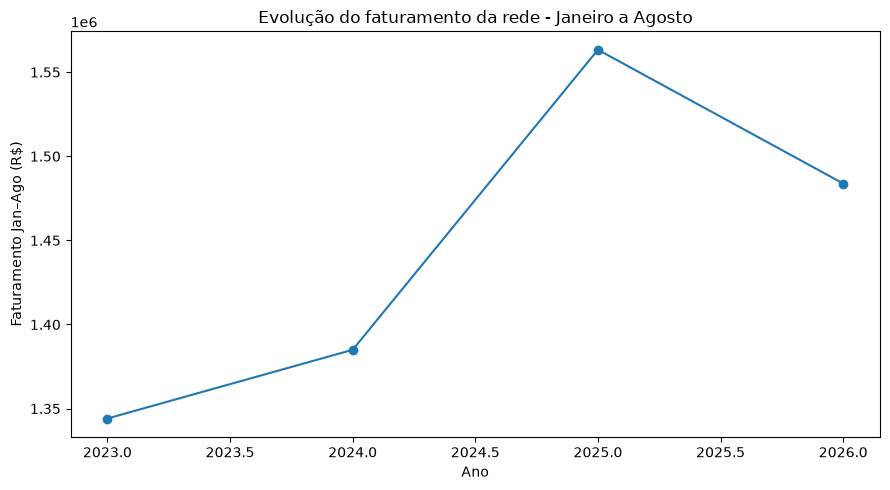

In [219]:
plt.figure(figsize=(9, 5))

plt.plot(
    evolucao['ano'],
    evolucao['faturamento'],
    marker='o'
)

plt.xlabel('Ano')
plt.ylabel('Faturamento Jan–Ago (R$)')
plt.title('Evolução do faturamento da rede - Janeiro a Agosto')

plt.tight_layout()
plt.show()

In [220]:
unidades_problematicas = [
    'NaraHoteis Centro',
    'NaraHoteis Nova Iguaçu Centro',
    'NaraHoteis Copacabana Premium'
]


problemas = jan_ago[
    jan_ago['nome_unidade'].isin(
        unidades_problematicas
    )
]

evolucao_problemas = (
    problemas
    .groupby(
        [
            'ano',
            'nome_unidade'
        ]
    )['faturamento']
    .sum()
    .reset_index()
)

evolucao_problemas

,ano,nome_unidade,faturamento
0,2023,NaraHoteis Centro,68050.0
1,2023,NaraHoteis Nova Iguaçu Centro,13000.0
2,2024,NaraHoteis Centro,73720.0
3,2024,NaraHoteis Nova Iguaçu Centro,61180.0
4,2025,NaraHoteis Centro,127640.0
5,2025,NaraHoteis Copacabana Premium,120640.0
6,2025,NaraHoteis Nova Iguaçu Centro,100520.0
7,2026,NaraHoteis Centro,31500.0
8,2026,NaraHoteis Copacabana Premium,121650.0
9,2026,NaraHoteis Nova Iguaçu Centro,97920.0


#### Resultados — as três unidades discrepantes ao longo do tempo

| Unidade | 2023 | 2024 | 2025 | 2026 |
|---|---|---|---|---|
| Centro | R$ 68.050,00 | R$ 73.720,00 | R$ 127.640,00 | **R$ 31.500,00** |
| Nova Iguaçu Centro | R$ 13.000,00 | R$ 61.180,00 | R$ 100.520,00 | R$ 97.920,00 |
| Copacabana Premium | — | — | R$ 120.640,00 | R$ 121.650,00 |

As três unidades que a Questão 03 classificou como discrepantes têm trajetórias completamente diferentes:

- **Centro — deterioração abrupta.** Depois de crescer até 2025, despenca **75,3%** em 2026, de R$ 127.640,00 para R$ 31.500,00. O número de reservas cai de 166 para 23, e **não há nenhuma reserva registrada em janeiro de 2026**. Combinado com a avaliação média de 2,19, é a unidade que exige atenção imediata.
- **Nova Iguaçu Centro — crescimento com estabilização.** Sai de R$ 13.000,00 em 2023 para o patamar de ~R$ 100 mil e se mantém. O faturamento acumulado baixo é herança do início fraco, não da situação atual. A avaliação de 2,17, porém, é o mesmo problema do Centro.
- **Copacabana Premium — unidade nova e estável.** Só aparece a partir de 2025 e já entra no mesmo patamar das outras duas, com leve crescimento em 2026. Seu faturamento acumulado é baixo simplesmente porque **participou de dois dos quatro anos analisados**.

O impacto do Centro na rede é direto: a queda de R$ 96.140,00 daquela unidade é **maior que a queda de R$ 79.510,00 da rede inteira**. Sem o Centro, o conjunto das demais unidades teria **crescido** cerca de R$ 16,6 mil em 2026.


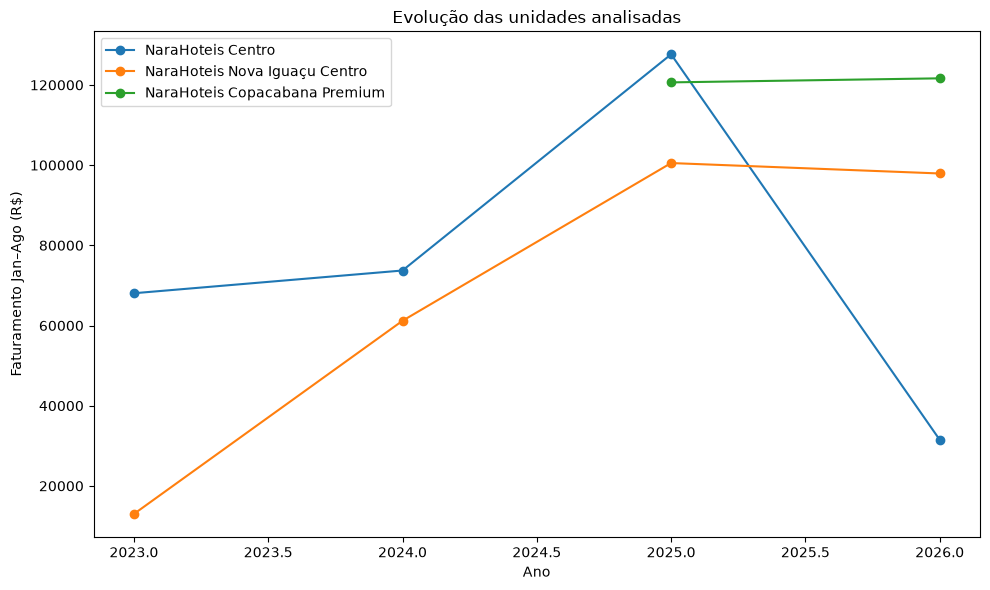

In [221]:
plt.figure(figsize=(10, 6))

for unidade in unidades_problematicas:

    dados = evolucao_problemas[
        evolucao_problemas['nome_unidade'] == unidade
    ]

    plt.plot(
        dados['ano'],
        dados['faturamento'],
        marker='o',
        label=unidade
    )

plt.xlabel('Ano')
plt.ylabel('Faturamento Jan–Ago (R$)')
plt.title('Evolução das unidades analisadas')

plt.legend()

plt.tight_layout()
plt.show()

## Conclusão — Questão 08

Comparando períodos equivalentes (janeiro a agosto), o faturamento da rede foi de **R$ 1.344.120,00 em 2023 para R$ 1.483.790,00 em 2026**, um crescimento acumulado de 10,4% em três anos, mas com trajetória irregular: +3,04% em 2024, **+12,88% em 2025** e **−5,09% em 2026**.

O recuo de 2026 **não é um fenômeno de rede**: ele é explicado quase inteiramente por uma única unidade. A queda do Centro (−R$ 96.140,00) supera a queda total da rede (−R$ 79.510,00); descontada essa unidade, as demais cresceram no período.

O cruzamento com a Questão 03 mostra que "faturamento baixo" agrupa três situações que exigem decisões opostas:

| Unidade | Diagnóstico | Ação sugerida |
|---|---|---|
| Centro | Deterioração real: −75,3% em 2026, avaliação 2,19, 23 reservas no ano | Investigação urgente — operacional e de coleta de dados |
| Nova Iguaçu Centro | Estabilizada em ~R$ 100 mil, mas com avaliação 2,17 | Foco em qualidade e valor da diária (R$ 398, a menor da rede) |
| Copacabana Premium | Unidade nova, estável e com o maior RevPAR real da rede | Manter e acompanhar — ver Questão 07 |

**Ressalvas.** O ano de 2026 contém apenas oito meses de dados, o que foi corretamente neutralizado pelo recorte Jan–Ago, mas impede qualquer projeção de fechamento anual. Além disso, a ausência total de reservas do Centro em janeiro de 2026 e o volume muito baixo no restante do ano levantam a hipótese de **falha de coleta**, e não apenas de queda de demanda — hipótese que precisa ser descartada antes de qualquer decisão sobre a unidade.


---

## Síntese geral das oito questões

| Questão | Resposta em uma linha |
|---|---|
| 01 | Estadia típica de 3,32 diárias (mediana 3), distribuição levemente assimétrica à direita e **sem outliers**; faturamento total de R$ 7,8 milhões, com dez unidades agrupadas e três destoantes. |
| 02 | **Três unidades ultrapassaram a capacidade** (Centro +31,67%, Nova Iguaçu Centro +28,00%, Copacabana +12,50%), mas os picos são pontuais e sugerem problema de registro. |
| 03 | **Três outliers, todos inferiores**: Centro, Nova Iguaçu Centro e Copacabana Premium. Nenhum outlier superior. |
| 04 | Correlação **positiva e moderada (r = 0,426)** entre avaliação e RevPAR, sem significância estatística com n = 13. |
| 05 | **RevPAR = 3,92 + 0,48 × avaliação**, com R² de 18,18% — a avaliação não é preditor confiável do RevPAR. |
| 06 | **Serra** é a região mais homogênea (CV de 2,7%); **Capital** é a mais desigual (CV de 31,8%), por composição de portfólio. |
| 07 | A Copacabana Premium é última em faturamento, mas **2ª da rede em RevPAR real (10,98)** — o problema era a métrica, não a unidade. |
| 08 | Crescimento até 2025 e **queda de 5,09% em 2026**, causada quase inteiramente pela unidade Centro. |

### O fio que une as questões

As três unidades apontadas como discrepantes na Questão 03 reaparecem em quase todas as outras, e a análise combinada mostra que elas **não compartilham o mesmo problema**:

- **Centro** e **Nova Iguaçu Centro** têm diária média em torno de R$ 400 (contra R$ 625 da rede) e avaliação de ~2,2 — são casos de **baixo valor agregado e insatisfação**, sendo o Centro o mais grave por causa do colapso de 2026.
- **Copacabana Premium** tem a **maior diária média da rede (R$ 800,22)**, o segundo maior RevPAR real e boa estabilidade. Aparece como outlier apenas porque opera desde janeiro de 2025.

A lição metodológica central do trabalho é essa: **o faturamento absoluto não é medida de desempenho** em uma rede com unidades de 40 a 120 quartos e idades diferentes. Sem normalizar por porte (receita por quarto) e por tempo (RevPAR sobre a janela real), a análise classifica a unidade mais eficiente da rede como a pior.

### Limitações gerais do estudo

- O faturamento é **estimado** (`qtd_diarias × valor_diaria_base`) e ignora descontos, comissões de canal (8% a 18%) e receitas acessórias.
- Os níveis absolutos de RevPAR (4 a 11) e de ocupação (menos de 2%) indicam que a base é uma **amostra de reservas**, não o histórico completo. Os indicadores valem como **comparação entre unidades**, não como medida operacional.
- Há sinais de dados sintéticos ou de importação irregular: picos de ocupação concentrados em pares de dias e ausência total de reservas do Centro em janeiro de 2026.
- Com **13 unidades**, todo teste estatístico tem baixo poder — correlações e regressões devem ser lidas como indício, não como evidência.


PAINEL PYHTON

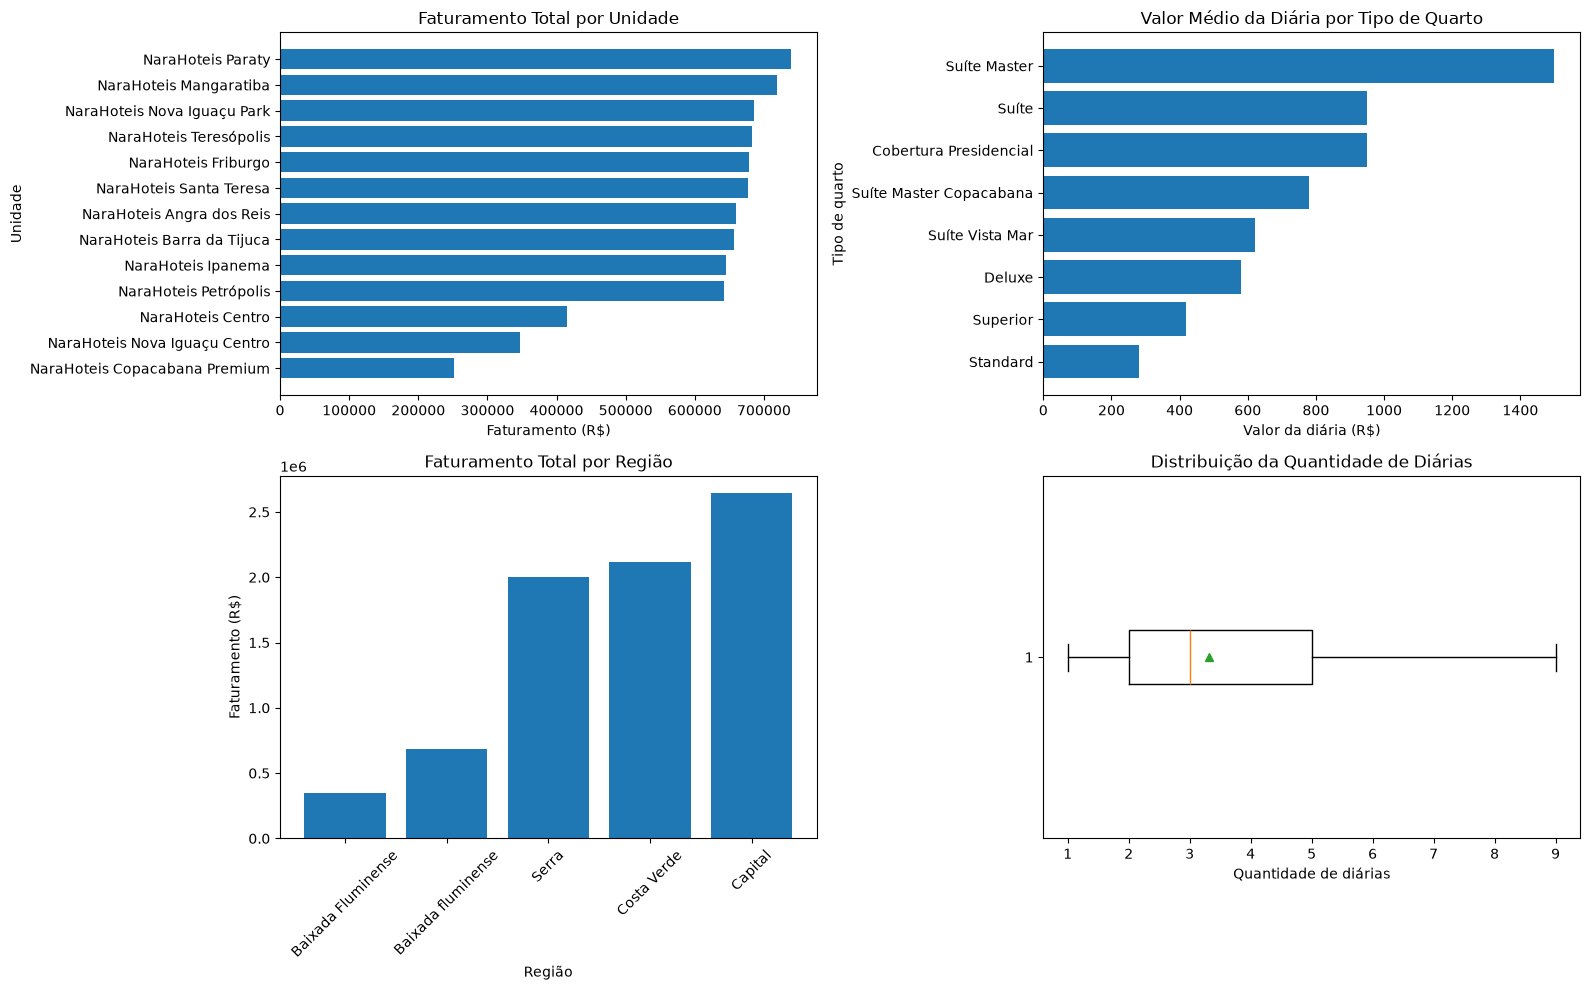

In [222]:
import matplotlib.pyplot as plt

# ============================================================
# 1. FATURAMENTO POR UNIDADE
# ============================================================

faturamento_unidade = (
    df_analise.groupby('nome_unidade')['faturamento']
    .sum()
    .sort_values()
)


# ============================================================
# 2. VALOR MÉDIO DA DIÁRIA POR TIPO DE QUARTO
# ============================================================

diaria_quarto = (
    quartos.groupby('descricao')['valor_diaria_base']
    .mean()
    .sort_values()
)


# ============================================================
# 3. FATURAMENTO POR REGIÃO
# ============================================================

faturamento_regiao = (
    df_analise.groupby('regiao')['faturamento']
    .sum()
    .sort_values()
)


# ============================================================
# 4. DISTRIBUIÇÃO DA QUANTIDADE DE DIÁRIAS
# ============================================================

qtd_diarias = df_analise['qtd_diarias']


# ============================================================
# 5. CRIAÇÃO DOS GRÁFICOS
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10)
)


# ------------------------------------------------------------
# Gráfico 1 — Faturamento por unidade
# ------------------------------------------------------------

axes[0, 0].barh(
    faturamento_unidade.index,
    faturamento_unidade.values
)

axes[0, 0].set_title(
    'Faturamento Total por Unidade'
)

axes[0, 0].set_xlabel(
    'Faturamento (R$)'
)

axes[0, 0].set_ylabel(
    'Unidade'
)


# ------------------------------------------------------------
# Gráfico 2 — Valor médio da diária por tipo de quarto
# ------------------------------------------------------------

axes[0, 1].barh(
    diaria_quarto.index,
    diaria_quarto.values
)

axes[0, 1].set_title(
    'Valor Médio da Diária por Tipo de Quarto'
)

axes[0, 1].set_xlabel(
    'Valor da diária (R$)'
)

axes[0, 1].set_ylabel(
    'Tipo de quarto'
)


# ------------------------------------------------------------
# Gráfico 3 — Faturamento por região
# ------------------------------------------------------------

axes[1, 0].bar(
    faturamento_regiao.index,
    faturamento_regiao.values
)

axes[1, 0].set_title(
    'Faturamento Total por Região'
)

axes[1, 0].set_xlabel(
    'Região'
)

axes[1, 0].set_ylabel(
    'Faturamento (R$)'
)

axes[1, 0].tick_params(
    axis='x',
    rotation=45
)


# ------------------------------------------------------------
# Gráfico 4 — Distribuição da quantidade de diárias
# ------------------------------------------------------------

axes[1, 1].boxplot(
    qtd_diarias,
    orientation="horizontal",
    showmeans=True
)

axes[1, 1].set_title(
    'Distribuição da Quantidade de Diárias'
)

axes[1, 1].set_xlabel(
    'Quantidade de diárias'
)


# ============================================================
# 6. AJUSTE FINAL
# ============================================================

plt.tight_layout()

plt.show()

In [223]:
# ============================================================
# NARAHOTEIS — EXPORTAÇÃO DO RELATÓRIO FINAL EM HTML
# ============================================================

from IPython.display import display, HTML
import base64
from io import BytesIO
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. FUNÇÃO PARA TRANSFORMAR GRÁFICOS EM IMAGEM
# ============================================================

def figura_base64(fig):
    buffer = BytesIO()
    fig.savefig(
        buffer,
        format="png",
        dpi=150,
        bbox_inches="tight",
        facecolor="white"
    )
    buffer.seek(0)

    imagem = base64.b64encode(
        buffer.read()
    ).decode("utf-8")

    plt.close(fig)

    return imagem


# ============================================================
# 2. CORES DO RELATÓRIO
# ============================================================

AZUL = "#2563EB"
AZUL_ESCURO = "#1E3A8A"
VERDE = "#16A34A"
VERDE_ESCURO = "#166534"
LARANJA = "#F59E0B"
VERMELHO = "#DC2626"
ROXO = "#7C3AED"
CIANO = "#0891B2"
CINZA = "#64748B"
CINZA_CLARO = "#F1F5F9"
BRANCO = "#FFFFFF"


# ============================================================
# 3. FUNÇÕES HTML
# ============================================================

def titulo_questao(numero, titulo, descricao, cor):

    return f"""
    <div class="questao-header"
         style="background: linear-gradient(135deg, {cor}, #111827);">

        <div class="questao-numero">
            QUESTÃO {numero}
        </div>

        <h2>{titulo}</h2>

        <p>{descricao}</p>

    </div>
    """


def card_resultado(texto, cor):

    return f"""
    <div class="resultado"
         style="border-left-color:{cor};">

        <div class="resultado-titulo"
             style="color:{cor};">
            RESULTADO
        </div>

        <div class="resultado-texto">
            {texto}
        </div>

    </div>
    """


def card_indicador(titulo, valor, descricao="", cor=AZUL):

    return f"""
    <div class="indicador"
         style="border-top-color:{cor};">

        <div class="indicador-titulo">
            {titulo}
        </div>

        <div class="indicador-valor"
             style="color:{cor};">

            {valor}

        </div>

        <div class="indicador-descricao">
            {descricao}
        </div>

    </div>
    """


def tabela_html(df, index=False):

    return df.to_html(
        index=index,
        classes="tabela",
        border=0,
        justify="center"
    )


# ============================================================
# 4. LISTA DE CONTEÚDO DO RELATÓRIO
# ============================================================

html = []


# ============================================================
# 5. CABEÇALHO / CAPA
# ============================================================

html.append(f"""

<div class="capa">

    <div class="capa-conteudo">

        <div class="capa-tag">
            PROJETO FINAL • SENAC
        </div>

        <h1>NARAHOTEIS</h1>

        <h2>
            Análise de Dados, Auditoria e Indicadores
        </h2>

        <p>
            Tratamento dos dados • Análise estatística •
            Indicadores operacionais • Desempenho financeiro
        </p>

    </div>

</div>

<div class="introducao">

    <h2>Objetivo da análise</h2>

    <p>
        Este relatório apresenta a análise dos dados da rede NaraHoteis,
        contemplando o tratamento das bases, análise estatística,
        identificação de inconsistências, avaliação de desempenho,
        relacionamento entre indicadores e evolução do faturamento.
    </p>

</div>

""")


# ============================================================
# 6. QUESTÃO 01
# ============================================================

fig = plt.figure(figsize=(10, 4))

plt.boxplot(
    df_analise["valor_diaria_base"],
    orientation="horizontal",
    showmeans=True,
    patch_artist=True,
    boxprops=dict(facecolor="#93C5FD"),
    medianprops=dict(
        color=AZUL_ESCURO,
        linewidth=2
    ),
    meanprops=dict(
        marker="D",
        markerfacecolor=LARANJA,
        markeredgecolor=LARANJA
    )
)

plt.title(
    "Distribuição dos Valores das Diárias",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Valor da diária (R$)")
plt.grid(axis="x", alpha=0.2)

imagem_q1 = figura_base64(fig)


html.append(
    titulo_questao(
        "01",
        "Comportamento dos valores das diárias",
        "Análise da distribuição dos valores das diárias praticadas pela rede.",
        AZUL
    )
)

html.append(f"""

<div class="texto">

    <h3>Principais indicadores</h3>

    <div class="indicadores">

        {card_indicador(
            "Média",
            f"R$ {media_diaria:,.2f}",
            "Valor médio das diárias",
            AZUL
        )}

        {card_indicador(
            "Mediana",
            f"R$ {mediana_diaria:,.2f}",
            "Valor central da distribuição",
            AZUL
        )}

        {card_indicador(
            "Menor diária",
            f"R$ {menor_diaria:,.2f}",
            "Menor valor observado",
            AZUL
        )}

        {card_indicador(
            "Maior diária",
            f"R$ {maior_diaria:,.2f}",
            "Maior valor observado",
            AZUL
        )}

        {card_indicador(
            "Amplitude",
            f"R$ {amplitude:,.2f}",
            "Diferença entre maior e menor valor",
            CIANO
        )}

        {card_indicador(
            "Q1",
            f"R$ {q1:,.2f}",
            "25% dos valores estão abaixo",
            CIANO
        )}

        {card_indicador(
            "Q3",
            f"R$ {q3:,.2f}",
            "75% dos valores estão abaixo",
            CIANO
        )}

        {card_indicador(
            "IQR",
            f"R$ {iqr:,.2f}",
            "Intervalo entre Q1 e Q3",
            CIANO
        )}

        {card_indicador(
            "Distância média-mediana",
            f"{distancia:.2%}",
            "Diferença relativa entre média e mediana",
            LARANJA
        )}

        {card_indicador(
            "Variância",
            f"{variancia_diaria:.2f}",
            "Dispersão dos valores ao redor da média",
            ROXO
        )}

        {card_indicador(
            "Desvio padrão",
            f"R$ {desvio_padrao:,.2f}",
            "Dispersão na mesma unidade da diária",
            ROXO
        )}

        {card_indicador(
            "Assimetria",
            f"{assimetria:.2f}",
            "Assimetria da distribuição",
            ROXO
        )}

        {card_indicador(
            "Curtose",
            f"{curtose:.2f}",
            "Formato/achatamento da distribuição",
            ROXO
        )}

    </div>

    <div class="grafico">
        <img src="data:image/png;base64,{imagem_q1}">
    </div>

</div>

""")

html.append(
    card_resultado(
        """
        A distribuição apresenta <b>assimetria positiva</b>.
        A mediana de <b>R$ 580,00</b> representa melhor o valor
        típico da diária do que a média de <b>R$ 612,95</b>.
        """,
        AZUL
    )
)


# ============================================================
# 7. QUESTÃO 02
# ============================================================

fig = plt.figure(figsize=(10, 5))

plt.bar(
    acima_capacidade["nome_unidade"],
    acima_capacidade["percentual_excesso"],
    color=LARANJA
)

plt.ylabel("Excesso sobre a capacidade (%)")

plt.title(
    "Unidades com Ocupação Acima da Capacidade",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=15)
plt.grid(axis="y", alpha=0.2)

imagem_q2 = figura_base64(fig)


html.append(
    titulo_questao(
        "02",
        "Ocupação acima da capacidade",
        "Identificação de registros de ocupação superiores à capacidade cadastrada.",
        LARANJA
    )
)

html.append(f"""

<div class="texto">

    <div class="periodo">
        <b>Período analisado:</b>
        {df_analise["data_checkin"].min().strftime("%d/%m/%Y")}
        a
        {df_analise["data_checkout"].max().strftime("%d/%m/%Y")}
    </div>

    <div class="grafico">
        <img src="data:image/png;base64,{imagem_q2}">
    </div>

    {tabela_html(
        acima_capacidade[
            [
                "nome_unidade",
                "num_quartos_total",
                "maior_ocupacao",
                "excesso",
                "percentual_excesso"
            ]
        ]
        .rename(
            columns={
                "num_quartos_total": "capacidade",
                "maior_ocupacao": "pico_ocupacao"
            }
        )
        .round(2)
    )}

</div>

""")

html.append(
    card_resultado(
        """
        Foram identificadas <b>3 unidades</b> com registros de
        ocupação acima da capacidade cadastrada:
        <b>Centro</b>, <b>Nova Iguaçu Centro</b> e
        <b>Copacabana Premium</b>.
        O resultado deve ser tratado como sinal de alerta e
        validado antes de ser interpretado como overbooking real.
        """,
        LARANJA
    )
)


# ============================================================
# 8. QUESTÃO 03
# ============================================================

faturamento_html = (
    df_analise
    .groupby("nome_unidade")["faturamento"]
    .sum()
    .reset_index()
)

fig = plt.figure(figsize=(10, 6))

plt.barh(
    faturamento_html["nome_unidade"],
    faturamento_html["faturamento"],
    color="#60A5FA"
)

plt.axvline(
    limite_inferior,
    color=VERMELHO,
    linestyle="--",
    linewidth=2,
    label="Limite inferior"
)

plt.axvline(
    limite_superior,
    color=VERDE,
    linestyle="--",
    linewidth=2,
    label="Limite superior"
)

plt.xlabel("Faturamento (R$)")
plt.ylabel("Unidade")

plt.title(
    "Faturamento por Unidade e Limites de Outliers",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="x", alpha=0.2)

imagem_q3 = figura_base64(fig)


html.append(
    titulo_questao(
        "03",
        "Faturamento discrepante",
        "Identificação de unidades com faturamento fora do padrão da rede.",
        VERMELHO
    )
)

html.append(f"""

<div class="texto">

    <div class="indicadores">

        {card_indicador(
            "Limite inferior",
            f"R$ {limite_inferior:,.0f}",
            "Limite pelo método do IQR",
            VERMELHO
        )}

        {card_indicador(
            "Limite superior",
            f"R$ {limite_superior:,.0f}",
            "Limite pelo método do IQR",
            VERDE
        )}

        {card_indicador(
            "Outliers",
            str(len(outliers)),
            "Unidades identificadas",
            VERMELHO
        )}

    </div>

    <div class="grafico">
        <img src="data:image/png;base64,{imagem_q3}">
    </div>

    {tabela_html(outliers)}

</div>

""")

html.append(
    card_resultado(
        """
        Foram identificadas <b>3 unidades discrepantes</b>,
        todas abaixo do limite inferior de
        <b>R$ 580.355,00</b>: Centro, Nova Iguaçu Centro e
        Copacabana Premium.
        Não houve outliers acima do limite superior.
        """,
        VERMELHO
    )
)


# ============================================================
# 9. QUESTÃO 04
# ============================================================

fig = plt.figure(figsize=(9, 5))

plt.scatter(
    revpar_avaliacao["avaliacao_media"],
    revpar_avaliacao["RevPAR"],
    s=90,
    color=ROXO,
    alpha=0.8
)

plt.xlabel("Avaliação média")
plt.ylabel("RevPAR")

plt.title(
    "Avaliação dos Hóspedes × RevPAR",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.2)

imagem_q4 = figura_base64(fig)


html.append(
    titulo_questao(
        "04",
        "Avaliação dos hóspedes × RevPAR",
        "Avaliação da relação entre a satisfação dos hóspedes e o RevPAR.",
        ROXO
    )
)

html.append(f"""

<div class="texto">

    <div class="indicadores">

        {card_indicador(
            "Correlação de Pearson",
            f"{r:.3f}",
            "Força e direção da relação",
            ROXO
        )}

        {card_indicador(
            "Direção",
            "Positiva",
            "As variáveis aumentam na mesma direção",
            VERDE
        )}

        {card_indicador(
            "Unidades",
            str(len(revpar_avaliacao)),
            "Unidades utilizadas na análise",
            ROXO
        )}

    </div>

    <div class="grafico">
        <img src="data:image/png;base64,{imagem_q4}">
    </div>

</div>

""")

html.append(
    card_resultado(
        """
        A correlação de Pearson foi <b>r = 0,426</b>,
        indicando uma relação <b>positiva e moderada</b>
        entre avaliação média e RevPAR.
        """,
        ROXO
    )
)


# ============================================================
# 10. QUESTÃO 05
# ============================================================

fig = plt.figure(figsize=(9, 5))

plt.scatter(
    x,
    y,
    s=85,
    color=VERDE,
    alpha=0.8,
    label="Unidades"
)

ordem = np.argsort(x)

plt.plot(
    x.iloc[ordem],
    y_previsto.iloc[ordem],
    color=AZUL_ESCURO,
    linewidth=2.5,
    label="Regressão linear"
)

plt.xlabel("Avaliação média")
plt.ylabel("RevPAR")

plt.title(
    "Regressão Linear — Avaliação × RevPAR",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(alpha=0.2)

imagem_q5 = figura_base64(fig)


html.append(
    titulo_questao(
        "05",
        "Estimativa do RevPAR a partir da avaliação",
        "Aplicação de regressão linear simples.",
        VERDE
    )
)

html.append(f"""

<div class="texto">

    <div class="indicadores">

        {card_indicador(
            "Coeficiente angular",
            f"{b1:.2f}",
            "Inclinação da reta",
            VERDE
        )}

        {card_indicador(
            "Intercepto",
            f"{b0:.2f}",
            "Valor estimado quando X = 0",
            VERDE
        )}

        {card_indicador(
            "R²",
            f"{r2:.2%}",
            "Poder explicativo do modelo",
            VERDE
        )}

    </div>

    <div class="equacao">
        <b>Equação do modelo:</b><br>
        RevPAR = {b0:.2f} + {b1:.2f} × Avaliação
    </div>

    <div class="grafico">
        <img src="data:image/png;base64,{imagem_q5}">
    </div>

</div>

""")

html.append(
    card_resultado(
        """
        Foi utilizada a regressão linear simples para avaliar a relação
        entre a avaliação média e o RevPAR. Os pontos estão dispersos,
        mas existe uma relação positiva. O <b>R² de 18,18%</b> indica que
        a avaliação média explica apenas <b>18,18% da variação observada
        no RevPAR</b>, indicando baixo poder explicativo do modelo.
        """,
        VERDE
    )
)

# ============================================================
# 11. QUESTÃO 06
# ============================================================

fig = plt.figure(figsize=(8, 5))

# Ordenar pelo desvio padrão
variabilidade_plot = variabilidade.sort_values(
    "desvio_padrao"
)

plt.bar(
    variabilidade_plot["regiao"],
    variabilidade_plot["desvio_padrao"],
    color=CIANO
)

plt.ylabel("Desvio padrão do faturamento (R$)")
plt.xlabel("Região")

plt.title(
    "Variabilidade do Faturamento por Região",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis="y", alpha=0.2)

imagem_q6 = figura_base64(fig)


# ------------------------------------------------------------
# TABELA FORMATADA PARA O HTML
# ------------------------------------------------------------

variabilidade_html = variabilidade.copy()

for coluna in ["media", "desvio_padrao"]:
    variabilidade_html[coluna] = (
        variabilidade_html[coluna]
        .apply(
            lambda x: (
                f"R$ {x:,.2f}"
                .replace(",", "X")
                .replace(".", ",")
                .replace("X", ".")
            )
        )
    )

# Selecionar somente as colunas que serão apresentadas
variabilidade_html = variabilidade_html[
    ["regiao", "media", "desvio_padrao"]
]

# Renomear colunas
variabilidade_html.columns = [
    "Região",
    "Média",
    "Desvio padrão"
]


# ------------------------------------------------------------
# TÍTULO DA QUESTÃO
# ------------------------------------------------------------

html.append(
    titulo_questao(
        "06",
        "Variabilidade do faturamento entre regiões",
        "Comparação da dispersão do faturamento entre as regiões por meio do desvio padrão.",
        CIANO
    )
)


# ------------------------------------------------------------
# GRÁFICO + TABELA
# ------------------------------------------------------------

html.append(f"""

<div class="texto">

    <div class="grafico">
        <img src="data:image/png;base64,{imagem_q6}">
    </div>

    {tabela_html(variabilidade_html)}

</div>

""")


# ------------------------------------------------------------
# RESULTADO
# ------------------------------------------------------------

html.append(
    card_resultado(
        """
        A <b>Baixada Fluminense</b> apresenta a maior
        variabilidade no faturamento, com desvio padrão de
        <b>R$ 239.277,86</b>.

        <br><br>

        Esse resultado indica uma elevada dispersão dos
        faturamentos das unidades em torno da média regional,
        que é de <b>R$ 516.325,00</b>.

        <br><br>

        A <b>Serra</b> apresenta a menor variabilidade,
        com desvio padrão de <b>R$ 22.398,35</b>,
        indicando maior homogeneidade no faturamento
        entre suas unidades.

        <br><br>

        A Baixada Fluminense possui apenas duas unidades,
        portanto esse resultado deve ser interpretado com
        cautela.
        """,
        CIANO
    )
)

# ============================================================
# 12. QUESTÃO 07
# ============================================================
# O CASO DA COPACABANA PREMIUM
# ============================================================

html.append(
    titulo_questao(
        "07",
        "O caso da unidade Copacabana Premium",
        "A menor receita da rede significa baixo desempenho?",
        ROXO
    )
)

html.append("""
<div class="texto">

    <p>
        A NaraHoteis Copacabana Premium é a <b>unidade com menor
        receita da rede</b>. A análise verifica se a receita total,
        isoladamente, é suficiente para avaliar o desempenho da unidade.
    </p>

    <p>
        Para isso, são considerados também o <b>porte da unidade</b>,
        a <b>receita por quarto</b>, o <b>RevPAR</b>, a
        <b>diária média</b> e o <b>tempo de operação</b>.
    </p>

</div>
""")

html.append(f"""
<div class="texto">

    <div class="indicadores">

        {card_indicador(
            "Receita estimada",
            "R$ 252.070",
            "Menor receita da rede",
            ROXO
        )}

        {card_indicador(
            "Receita por quarto",
            "R$ 6.301,75",
            "34,8% abaixo da média da rede",
            ROXO
        )}

        {card_indicador(
            "RevPAR corrigido",
            "10,98",
            "2º maior RevPAR da rede",
            VERDE
        )}

        {card_indicador(
            "Diária média",
            "R$ 800,22",
            "Maior diária média da rede",
            VERDE
        )}

    </div>

</div>
""")

html.append("""
<div class="texto">

    <h3>Copacabana Premium × demais unidades</h3>

    <table class="tabela">

        <thead>
            <tr>
                <th>Indicador</th>
                <th>Copacabana Premium</th>
                <th>Demais unidades</th>
            </tr>
        </thead>

        <tbody>

            <tr>
                <td>Receita estimada</td>
                <td><b>R$ 252.070,00</b></td>
                <td>R$ 347.130,00 a R$ 739.380,00</td>
            </tr>

            <tr>
                <td>Receita por quarto</td>
                <td><b>R$ 6.301,75</b></td>
                <td>Média de R$ 9.664,59</td>
            </tr>

            <tr>
                <td>Diferença contra a média</td>
                <td><b>−34,8%</b></td>
                <td>—</td>
            </tr>

            <tr>
                <td>Quartos</td>
                <td><b>40</b></td>
                <td>45 a 120</td>
            </tr>

            <tr>
                <td>Reservas válidas</td>
                <td><b>112</b></td>
                <td>271 a 410</td>
            </tr>

            <tr>
                <td>Diárias vendidas</td>
                <td><b>315</b></td>
                <td>872 a 1.105</td>
            </tr>

        </tbody>

    </table>

</div>
""")

receita_plot = (
    faturamento_unidade
    .reset_index()
    .rename(columns={"faturamento": "receita_total"})
    .sort_values("receita_total", ascending=True)
)

fig = plt.figure(figsize=(10, 7))

plt.barh(
    receita_plot["nome_unidade"],
    receita_plot["receita_total"],
    color="#93C5FD"
)

plt.axvline(
    receita_plot["receita_total"].mean(),
    color=ROXO,
    linestyle="--",
    linewidth=2,
    label="Média da rede"
)

plt.xlabel("Receita estimada (R$)")
plt.ylabel("Unidade")

plt.title(
    "Receita Estimada por Unidade",
    fontsize=15,
    fontweight="bold"
)

plt.legend()
plt.grid(axis="x", alpha=0.2)

imagem_q7_receita = figura_base64(fig)

html.append(f"""
<div class="texto">

    <h3>Receita estimada por unidade</h3>

    <div class="grafico">
        <img src="data:image/png;base64,{imagem_q7_receita}">
    </div>

</div>
""")

html.append("""
<div class="texto">

    <h3>Comparação entre unidades 5 estrelas</h3>

    <table class="tabela">

        <thead>
            <tr>
                <th>Unidade 5 estrelas</th>
                <th>RevPAR</th>
                <th>Diária média</th>
                <th>Receita/quarto</th>
                <th>Quartos</th>
                <th>Dias</th>
            </tr>
        </thead>

        <tbody>

            <tr>
                <td><b>Copacabana Premium</b></td>
                <td><b>10,98</b></td>
                <td><b>R$ 800,22</b></td>
                <td>R$ 6.301,75</td>
                <td>40</td>
                <td>574</td>
            </tr>

            <tr>
                <td>Paraty</td>
                <td>7,36</td>
                <td>R$ 683,98</td>
                <td>R$ 9.858,40</td>
                <td>75</td>
                <td>1.340</td>
            </tr>

            <tr>
                <td>Petrópolis</td>
                <td>6,85</td>
                <td>R$ 636,60</td>
                <td>R$ 9.167,00</td>
                <td>70</td>
                <td>1.338</td>
            </tr>

            <tr>
                <td>Ipanema</td>
                <td>6,07</td>
                <td>R$ 631,30</td>
                <td>R$ 8.057,00</td>
                <td>80</td>
                <td>1.327</td>
            </tr>

            <tr>
                <td>Angra dos Reis</td>
                <td>5,52</td>
                <td>R$ 682,12</td>
                <td>R$ 7.336,56</td>
                <td>90</td>
                <td>1.328</td>
            </tr>

        </tbody>

    </table>

</div>
""")

html.append(f"""
<div class="texto">

    <div class="indicadores">

        {card_indicador(
            "Tempo de operação",
            "574 dias",
            "Primeiro check-in em 24/01/2025",
            ROXO
        )}

        {card_indicador(
            "Capacidade",
            "40 quartos",
            "Menor capacidade da rede",
            ROXO
        )}

        {card_indicador(
            "RevPAR",
            "10,98",
            "41,9% acima da média da rede",
            VERDE
        )}

        {card_indicador(
            "Diária média",
            "R$ 800,22",
            "Maior valor da rede",
            VERDE
        )}

    </div>

</div>
""")

html.append(
    card_resultado(
        """
        A NaraHoteis Copacabana Premium é a <b>última colocada em
        receita estimada (R$ 252.070,00)</b> e está 34,8% abaixo da
        média da rede em receita por quarto.

        <br><br>

        Entretanto, a receita acumulada não deve ser interpretada
        isoladamente. A unidade possui apenas <b>40 quartos</b> e
        opera há <b>574 dias</b>, enquanto as demais unidades
        comparáveis possuem períodos de operação muito maiores.

        <br><br>

        Quando os indicadores são normalizados por capacidade e
        tempo de operação, o cenário muda: o <b>RevPAR corrigido
        é de 10,98</b>, o <b>2º maior da rede</b> e o maior entre
        as unidades 5 estrelas analisadas.

        <br><br>

        A diária média de <b>R$ 800,22</b> também é a maior da rede.
        Portanto, o baixo faturamento acumulado está relacionado
        principalmente ao <b>menor tempo de operação e ao menor
        volume acumulado de diárias vendidas</b>.
        """,
        ROXO
    )
)


# 13. QUESTÃO 08
# ============================================================

fig = plt.figure(figsize=(9, 5))

plt.plot(
    evolucao["ano"],
    evolucao["faturamento"],
    marker="o",
    linewidth=3,
    markersize=8,
    color=AZUL
)

plt.xlabel("Ano")
plt.ylabel("Faturamento Jan–Ago (R$)")

plt.title(
    "Evolução do Faturamento — Janeiro a Agosto",
    fontsize=15,
    fontweight="bold"
)

plt.grid(alpha=0.2)

imagem_q8 = figura_base64(fig)


html.append(
    titulo_questao(
        "08",
        "Evolução do faturamento",
        "Comparação do faturamento em períodos equivalentes de janeiro a agosto.",
        AZUL_ESCURO
    )
)

html.append(f"""

<div class="texto">

    <div class="grafico">
        <img src="data:image/png;base64,{imagem_q8}">
    </div>

    {tabela_html(
        evolucao.round(2)
    )}

</div>

""")

html.append(
    card_resultado(
        """
        Considerando sempre o período de <b>janeiro a agosto</b>,
        o faturamento apresentou crescimento até 2025.
        Em 2026 houve redução de <b>5,09%</b> em relação a 2025,
        embora o valor permaneça acima do observado no mesmo período
        de 2023.
        """,
        AZUL_ESCURO
    )
)


# ============================================================
# 14. PAINEL FINAL
# ============================================================

html.append(f"""

<div class="painel-final">

    <div class="painel-tag">
        PAINEL EXECUTIVO
    </div>

    <h1>NARAHOTEIS</h1>

    <p class="painel-subtitulo">
        Principais resultados da análise
    </p>

    <div class="painel-grid">

        <div class="painel-card">
            <div class="painel-card-numero">Q1</div>
            <h3>Diárias</h3>
            <strong>R$ 612,95</strong>
            <p>Média</p>
            <small>Mediana: R$ 580,00</small>
        </div>

        <div class="painel-card">
            <div class="painel-card-numero">Q2</div>
            <h3>Capacidade</h3>
            <strong>3</strong>
            <p>Unidades acima da capacidade</p>
        </div>

        <div class="painel-card">
            <div class="painel-card-numero">Q3</div>
            <h3>Outliers</h3>
            <strong>3</strong>
            <p>Unidades abaixo do limite inferior</p>
        </div>

        <div class="painel-card">
            <div class="painel-card-numero">Q4</div>
            <h3>Correlação</h3>
            <strong>0,426</strong>
            <p>Relação positiva e moderada</p>
        </div>

        <div class="painel-card">
            <div class="painel-card-numero">Q5</div>
            <h3>Modelo</h3>
            <strong>18,18%</strong>
            <p>R²</p>
            <small>Baixo poder explicativo</small>
        </div>

        <div class="painel-card">
            <div class="painel-card-numero">Q6</div>
            <h3>Variabilidade</h3>
            <strong>2,7%</strong>
            <p>CV da Serra</p>
            <small>Maior homogeneidade</small>
        </div>

        <div class="painel-card">
            <div class="painel-card-numero">Q7</div>
            <h3>Copacabana Premium</h3>
            <strong>10,98</strong>
            <p>RevPAR corrigido</p>
            <small>2º maior da rede</small>
        </div>

        <div class="painel-card painel-card-largo">
            <div class="painel-card-numero">Q8</div>
            <h3>Faturamento Jan–Ago 2026</h3>
            <strong>R$ 1.483.790</strong>
            <p>−5,09% em relação a 2025</p>
        </div>

    </div>

</div>

""")


# ============================================================
# 15. CONCLUSÃO GERAL
# ============================================================

html.append(f"""

<div class="conclusao">

    <h2>Conclusão Geral</h2>

    <p>
        A análise da NaraHoteis permitiu avaliar o comportamento das
        diárias, a capacidade operacional, o faturamento das unidades,
        a relação entre avaliação dos hóspedes e RevPAR, a variabilidade
        regional e a evolução temporal da receita.
    </p>

    <p>
        Os resultados mostram diferenças importantes entre as unidades
        e regiões, além de registros que merecem validação operacional,
        especialmente os casos de ocupação acima da capacidade cadastrada
        e os faturamentos classificados como discrepantes.
    </p>

    <p>
        A relação entre avaliação média e RevPAR é positiva, porém o
        modelo de regressão apresenta baixo poder explicativo,
        indicando que outros fatores devem ser considerados para explicar
        o desempenho financeiro das unidades.
    </p>

    <p>
        A Questão 07 mostra que a Copacabana Premium, embora apresente
        a menor receita acumulada, possui RevPAR corrigido de 10,98,
        o segundo maior da rede. Isso evidencia a importância de
        considerar capacidade e tempo de operação na avaliação do desempenho.
    </p>

</div>

""")


# ============================================================
# 16. CSS COMPLETO
# ============================================================

css = f"""

<style>

* {{
    box-sizing: border-box;
}}

body {{
    margin: 0;
    background: #F1F5F9;
    color: #1E293B;
    font-family: Arial, Helvetica, sans-serif;
}}

.relatorio {{
    max-width: 1200px;
    margin: auto;
    background: white;
}}

.capa {{
    min-height: 430px;
    display: flex;
    align-items: center;
    padding: 60px;
    color: white;

    background:
        linear-gradient(
            135deg,
            #1E3A8A 0%,
            #312E81 55%,
            #0F172A 100%
        );

    border-radius: 0 0 22px 22px;
}}

.capa-tag,
.painel-tag {{
    display: inline-block;
    padding: 8px 14px;
    border-radius: 20px;
    background: rgba(255,255,255,.15);
    font-size: 12px;
    font-weight: bold;
    letter-spacing: 1px;
}}

.capa h1 {{
    font-size: 58px;
    margin: 20px 0 5px 0;
}}

.capa h2 {{
    font-size: 25px;
    font-weight: normal;
    margin: 0 0 20px 0;
}}

.capa p {{
    font-size: 16px;
    max-width: 700px;
    line-height: 1.7;
}}

.introducao,
.texto,
.conclusao {{
    padding: 30px 45px;
}}

.introducao {{
    background: white;
}}

.introducao h2,
.conclusao h2 {{
    color: #1E3A8A;
}}

.introducao p,
.conclusao p {{
    line-height: 1.8;
    font-size: 15px;
}}

.questao-header {{
    margin-top: 45px;
    padding: 25px 45px;
    color: white;
}}

.questao-numero {{
    font-size: 12px;
    font-weight: bold;
    letter-spacing: 2px;
    opacity: .85;
}}

.questao-header h2 {{
    margin: 8px 0;
    font-size: 28px;
}}

.questao-header p {{
    margin: 0;
    font-size: 14px;
    opacity: .9;
}}

.indicadores {{
    display: grid;
    grid-template-columns: repeat(4, 1fr);
    gap: 15px;
    margin: 20px 0 30px 0;
}}

.indicador {{
    background: white;
    border-top: 5px solid;
    padding: 18px;
    border-radius: 10px;
    box-shadow: 0 3px 12px rgba(15,23,42,.08);
}}

.indicador-titulo {{
    font-size: 12px;
    color: #64748B;
    text-transform: uppercase;
    font-weight: bold;
}}

.indicador-valor {{
    font-size: 25px;
    font-weight: bold;
    margin: 8px 0;
}}

.indicador-descricao {{
    font-size: 12px;
    color: #64748B;
}}

.periodo {{
    background: #FFF7ED;
    border-left: 5px solid #F59E0B;
    padding: 14px 18px;
    margin: 10px 0 20px 0;
    border-radius: 8px;
    color: #334155;
    font-size: 14px;
}}

.grafico {{
    background: white;
    padding: 15px;
    margin: 20px 0;
    border-radius: 12px;
    text-align: center;
    box-shadow: 0 3px 12px rgba(15,23,42,.06);
}}

.grafico img {{
    max-width: 100%;
    height: auto;
}}

.resultado {{
    margin: 0 45px 35px 45px;
    padding: 20px 24px;
    background: #F8FAFC;
    border-left: 6px solid;
    border-radius: 8px;
}}

.resultado-titulo {{
    font-weight: bold;
    font-size: 13px;
    letter-spacing: 1px;
    margin-bottom: 8px;
}}

.resultado-texto {{
    line-height: 1.7;
    font-size: 15px;
}}

.tabela {{
    width: 100%;
    border-collapse: collapse;
    margin: 25px 0;
    font-size: 13px;
}}

.tabela th {{
    background: #1E3A8A;
    color: white;
    padding: 10px;
}}

.tabela td {{
    padding: 9px;
    border-bottom: 1px solid #E2E8F0;
    text-align: center;
}}

.tabela tr:nth-child(even) {{
    background: #F8FAFC;
}}

.equacao {{
    background: #ECFDF5;
    border: 1px solid #86EFAC;
    padding: 18px;
    border-radius: 10px;
    text-align: center;
    font-size: 18px;
    margin: 20px 0;
}}

.painel-final {{
    margin-top: 55px;
    padding: 50px 45px;
    color: white;

    background:
        linear-gradient(
            135deg,
            #0F172A,
            #1E3A8A,
            #312E81
        );
}}

.painel-final h1 {{
    font-size: 42px;
    margin: 18px 0 5px 0;
}}

.painel-subtitulo {{
    color: #CBD5E1;
    margin-bottom: 35px;
}}

.painel-grid {{
    display: grid;
    grid-template-columns: repeat(3, 1fr);
    gap: 18px;
}}

.painel-card {{
    background: rgba(255,255,255,.09);
    border: 1px solid rgba(255,255,255,.15);
    border-radius: 14px;
    padding: 22px;
    min-height: 180px;
}}

.painel-card-largo {{
    grid-column: span 3;
}}

.painel-card-numero {{
    color: #93C5FD;
    font-size: 12px;
    font-weight: bold;
    letter-spacing: 1px;
}}

.painel-card h3 {{
    margin: 12px 0;
}}

.painel-card strong {{
    display: block;
    font-size: 28px;
    color: white;
}}

.painel-card p {{
    color: #CBD5E1;
    margin: 7px 0;
}}

.painel-card small {{
    color: #94A3B8;
}}

.conclusao {{
    background: white;
    margin-top: 0;
    padding-top: 45px;
    padding-bottom: 60px;
}}

@media (max-width: 800px) {{

    .indicadores {{
        grid-template-columns: repeat(2, 1fr);
    }}

    .painel-grid {{
        grid-template-columns: 1fr;
    }}

    .painel-card-largo {{
        grid-column: span 1;
    }}

    .capa {{
        padding: 35px;
    }}

    .capa h1 {{
        font-size: 42px;
    }}

    .questao-header,
    .texto {{
        padding-left: 25px;
        padding-right: 25px;
    }}

    .resultado {{
        margin-left: 25px;
        margin-right: 25px;
    }}

}}

</style>

"""


# ============================================================
# 17. MONTAR HTML FINAL
# ============================================================

html_final = f"""
<!DOCTYPE html>

<html lang="pt-BR">

<head>

<meta charset="UTF-8">

<meta name="viewport"
      content="width=device-width, initial-scale=1.0">

<title>NaraHoteis — Análise de Dados</title>

{css}

</head>

<body>

<div class="relatorio">

{''.join(html)}

</div>

</body>

</html>
"""


# ============================================================
# 18. SALVAR ARQUIVO
# ============================================================

arquivo_html = Path(
    "NaraHoteis_Relatorio_Final.html"
)

arquivo_html.write_text(
    html_final,
    encoding="utf-8"
)


# ============================================================
# 19. MENSAGEM DE CONFIRMAÇÃO
# ============================================================

display(
    HTML(
        f"""
        <div style="
            background:#ECFDF5;
            border-left:6px solid #16A34A;
            padding:20px;
            border-radius:8px;
            margin:20px 0;
            font-family:Arial;
        ">

        <h3 style="color:#166534;margin-top:0;">
            HTML gerado com sucesso
        </h3>

        <p>
            Arquivo:
            <b>{arquivo_html.name}</b>
        </p>

        <p>
            O relatório contém as questões, gráficos,
            resultados, tabelas e o painel executivo final.
        </p>

        </div>
        """
    )
)
